# <center style="font-weight: bold; color: #0098cd;">Procesamiento y análisis de audio</center>

## 1. Introducción

El procesamiento de audios procedentes de entornos reales presenta una elevada variabilidad en términos de calidad, formato, duración y condiciones de captura. Esta heterogeneidad introduce dificultades directas en su uso dentro de sistemas de reconocimiento automático del habla (*Automatic Speech Recognition*, ASR), que requieren señales de entrada consistentes y adecuadamente estructuradas.

Este *notebook* aborda la etapa de preprocesamiento de audio, centrada en la adaptación de las señales de entrada mediante un conjunto de transformaciones orientadas a mejorar su calidad y homogeneidad. Para ello, se combinan una fase experimental, en la que se analizan distintas técnicas de procesamiento de señal, y una fase de implementación en la que se define un *pipeline* final reproducible basado en las decisiones adoptadas.

### 1.1 Objetivo

El objetivo de este *notebook* es diseñar e implementar un pipeline de preprocesamiento de audio que permita generar señales homogéneas y adecuadas para su uso en sistemas ASR, a partir del análisis previo de distintas técnicas de procesamiento y su impacto sobre la señal.

### 1.2 Contexto dentro del sistema completo

El preprocesamiento de audio constituye la primera etapa del sistema, actuando como interfaz entre los datos de entrada y el módulo de ASR. Su función es adaptar la señal a los requisitos del modelo, reduciendo la variabilidad que podría afectar negativamente al rendimiento del sistema.

### 1.3 Requisitos de esta fase

El desarrollo del *pipeline* de preprocesamiento se rige por una serie de requisitos técnicos que condicionan tanto la fase experimental como la implementación final.

En primer lugar, se requiere garantizar la homogeneidad de las señales de entrada, transformando todos los audios a un formato común (WAV, mono, 16 kHz) que sea compatible con los modelos ASR y permita eliminar la variabilidad derivada de los dispositivos de captura.

En segundo lugar, el sistema debe ser robusto frente a condiciones reales, lo que implica la evaluación y selección de técnicas de mejora de señal como la reducción de ruido, el filtrado de frecuencias no deseadas y la normalización de amplitud. Estas transformaciones deben aplicarse de forma controlada, evitando introducir distorsiones que puedan afectar negativamente al reconocimiento.

Asimismo, es necesario gestionar la presencia de silencios tanto en los extremos como en el interior de la señal, mediante técnicas de *trimming* y modelos de detección de actividad de voz (VAD), con el objetivo de optimizar la información relevante proporcionada al sistema.

Adicionalmente, el proceso debe ser modular y reproducible, estructurando cada etapa del *pipeline* como una función independiente que permita su análisis y validación. Este enfoque facilita la transición desde la fase experimental hacia un *pipeline* final definido.

Por último, se establece como principio de diseño evitar el sobreprocesamiento de la señal, limitando las transformaciones a aquellas que aportan valor real. Esta decisión se fundamenta en el hecho de que modelos como Whisper ya incorporan mecanismos internos de procesamiento, por lo que la aplicación excesiva de transformaciones externas no garantiza mejoras en el rendimiento y puede incluso resultar perjudicial.

## 2. Preparación del entorno de trabajo

En esta sección se define el entorno de trabajo necesario para el procesamiento de audio, incluyendo la instalación de dependencias, la importación de librerías y la configuración de rutas.

Esta estructura permite garantizar la reproducibilidad del *pipeline* y facilitar la trazabilidad de los datos a lo largo de las distintas fases del procesamiento.

### 2.1 Instalación de dependencias

In [91]:
# ============================================
# CONFIGURACIÓN DEL ENTORNO
# ============================================
# Este notebook requiere la instalación previa de las dependencias del proyecto.
# Ejecutar en terminal:
# pip install -r requirements.txt

### 2.2 Importación de librerías

In [92]:
# ==============================
# Manipulación numérica y señales
# ==============================
import numpy as np                          # operaciones numéricas
import librosa                              # procesamiento de audio
from scipy.signal import butter, filtfilt   # filtros de señal

# ==============================
# Procesamiento de audio
# ==============================
import soundfile as sf                      # lectura/escritura de audio
from pydub import AudioSegment              # conversión de formatos (m4a → wav)
import noisereduce as nr                    # reducción de ruido

# ==============================
# Modelos de IA (VAD)
# ==============================
import torch                                # backend para modelos
from silero_vad import load_silero_vad, get_speech_timestamps  # VAD

# ==============================
# Manejo de datos
# ==============================
import pandas as pd                         # datos tabulares

# ==============================
# Visualización y análisis
# ==============================
import matplotlib.pyplot as plt             # visualización
from IPython.display import Audio, display  # reproducción en notebook

# ==============================
# Sistema y utilidades
# ==============================
from pathlib import Path                    # gestión de rutas
import random                               # generación de números aleatorios

### 2.3 Gestión y configuración de rutas

In [93]:
# Detectar raíz
project_root = Path.cwd()

while not (project_root / "data").exists():
    project_root = project_root.parent

# Directorios
data_dir = project_root / "data"

raw_audio_dir = data_dir / "raw_audio"
standardized_audio_dir = data_dir / "standardized_audio"
processed_audio_dir = data_dir / "processed_audio"

# Crear carpetas
standardized_audio_dir.mkdir(parents=True, exist_ok=True)
processed_audio_dir.mkdir(parents=True, exist_ok=True)

# Verificación
print("Ruta raíz:", project_root)
print("Audios originales:", raw_audio_dir)
print("Audios estandarizados:", standardized_audio_dir)
print("Audios procesados (final):", processed_audio_dir)

Ruta raíz: /Volumes/EXTENSION/GitHub/TFM
Audios originales: /Volumes/EXTENSION/GitHub/TFM/data/raw_audio
Audios estandarizados: /Volumes/EXTENSION/GitHub/TFM/data/standardized_audio
Audios procesados (final): /Volumes/EXTENSION/GitHub/TFM/data/processed_audio


## 3. Análisis inicial del audio original

Antes de definir el *pipeline* de preprocesamiento, se realiza un análisis exploratorio de los audios originales con el objetivo de caracterizar sus propiedades y detectar posibles fuentes de variabilidad. Esta fase permite comprender el estado real de las señales de entrada, identificando aspectos como el formato de archivo, la frecuencia de muestreo, el número de canales o la duración de las grabaciones.

A partir de este análisis, se establecen criterios objetivos para la transformación posterior de los audios, definiendo reglas de decisión que permiten determinar de forma sistemática qué operaciones deben aplicarse a cada señal. De este modo, el preprocesamiento no se plantea como una serie de transformaciones arbitrarias, sino como un proceso guiado por las características observadas en los datos.

Esta etapa constituye, por tanto, la base para la construcción del *pipeline* final, asegurando que las decisiones adoptadas estén fundamentadas en el comportamiento real del conjunto de audios y no en supuestos teóricos.

### 3.1 Carga de audios

In [94]:
# Extensiones válidas
VALID_EXTENSIONS = {".wav", ".mp3", ".m4a", ".flac", ".ogg"}

# Filtrado de archivos de audio
audio_files = [
    f for f in raw_audio_dir.iterdir()
    if f.is_file() and f.suffix.lower() in VALID_EXTENSIONS
]

# Verificación
if len(audio_files) == 0:
    raise FileNotFoundError("No se han encontrado audios válidos en el directorio")

print(f"Se han encontrado {len(audio_files)} audios válidos")

# Dataset
audio_dataset = [{"path": f} for f in audio_files]

Se han encontrado 11 audios válidos


En esta fase se identifican los archivos de audio disponibles en el directorio de entrada y se construye una estructura inicial basada únicamente en sus rutas.

A diferencia de una carga completa en memoria, se adopta un enfoque diferido (lazy loading), evitando almacenar directamente las señales de audio. Esta decisión permite escalar el pipeline a conjuntos de datos de mayor tamaño sin penalizar el uso de memoria y facilita aplicar estrategias de carga específicas en función de cada etapa del procesamiento.

### 3.2 Extracción de metadatos

In [95]:
# Análisis inicial de los audios originales para caracterizar sus propiedades básicas
print("=== Información del audio original ===")

# Lista para almacenar la información estructurada de cada audio
rows = []

# Iteramos sobre cada audio del dataset
for item in audio_dataset:

    audio_path = item["path"]

    try:
        # Lectura eficiente de metadatos sin cargar completamente el audio
        info = sf.info(audio_path)

        samplerate = info.samplerate
        channels = info.channels
        duration = info.duration
        format_ = info.format
        subtype = info.subtype

    except:
        # Fallback para formatos no soportados directamente (ej: comprimidos)
        audio = AudioSegment.from_file(audio_path)

        samplerate = audio.frame_rate
        channels = audio.channels
        duration = len(audio) / 1000
        format_ = audio_path.suffix.replace(".", "").upper()
        subtype = "compressed"

    # Se añaden los metadatos al dataset original (enriquecimiento)
    item["samplerate"] = samplerate
    item["channels"] = channels
    item["duration_sec"] = duration
    item["format"] = format_
    item["subtype"] = subtype

    # Se construye una fila para análisis tabular
    rows.append({
        "file": audio_path.name,
        "format": format_,
        "samplerate": samplerate,
        "channels": channels,
        "duration_sec": round(duration, 2)
    })

# Conversión a DataFrame para facilitar el análisis
df_audio = pd.DataFrame(rows)

# Resumen global del dataset
print(f"\nTotal audios: {len(df_audio)}")
print(f"Duración media: {df_audio['duration_sec'].mean():.2f}s")
print(f"Sample rates: {df_audio['samplerate'].unique()}")
print(f"Formatos: {df_audio['format'].unique()}")

# Muestra representativa de los audios
print("\nEjemplo de audios:")
display(df_audio.head(5))

=== Información del audio original ===

Total audios: 11
Duración media: 48.87s
Sample rates: [48000]
Formatos: <ArrowStringArray>
['M4A']
Length: 1, dtype: str

Ejemplo de audios:


,file,format,samplerate,channels,duration_sec
0,AUDIO-2025-09-18-13-34-03.m4a,M4A,48000,1,8.36
1,AUDIO-2026-03-12-09-54-36.m4a,M4A,48000,1,11.78
2,AUDIO-2026-04-21-17-26-57.m4a,M4A,48000,1,66.32
3,AUDIO-2026-04-22-11-23-01.m4a,M4A,48000,1,10.56
4,AUDIO-2026-04-22-11-24-06.m4a,M4A,48000,1,63.36


Durante la extracción de metadatos se utiliza `soundfile` como método principal, debido a su eficiencia al acceder a la información del archivo sin necesidad de cargar completamente la señal. Sin embargo, esta librería presenta limitaciones en el soporte de formatos comprimidos habituales en aplicaciones de mensajería, como m4a (AAC) u ogg (Opus).

Por este motivo, se implementa un mecanismo de respaldo (*fallback*) mediante `pydub`, que permite decodificar estos formatos y extraer sus propiedades básicas. Aunque `pydub` no está orientado al análisis de señal, resulta útil en esta fase para garantizar la compatibilidad con audios reales.

Este enfoque híbrido permite mantener la robustez del *pipeline* frente a la heterogeneidad de formatos, característica habitual en entornos no controlados.

### 3.3 Validación del audio y generación de reglas de procesamiento

introduccion aqui

#### 3.3.1 Definición de reglas de decisión

In [96]:
# Aplicación de reglas de decisión basadas en los metadatos del audio

for item in audio_dataset:

    samplerate = item["samplerate"]
    channels = item["channels"]
    format_ = item["format"]
    duration = item["duration_sec"]

    # Determinación de necesidades de procesamiento
    item["needs_resample"] = samplerate != 16000
    item["needs_mono"] = channels > 1
    item["needs_conversion"] = format_ not in ["WAV", "FLAC"]

    # Clasificación básica de calidad en función de la duración
    if duration < 1:
        item["quality_flag"] = "too_short"
    elif duration > 60:
        item["quality_flag"] = "too_long"
    else:
        item["quality_flag"] = "ok"

#### 3.3.2 Análisis de las reglas generadas

In [97]:
rows = []

for item in audio_dataset:

    rows.append({
        "file": item["path"].name,
        "needs_resample": item["needs_resample"],
        "needs_mono": item["needs_mono"],
        "needs_conversion": item["needs_conversion"],
        "duration_sec": item["duration_sec"],
        "quality_flag": item["quality_flag"]
    })

df_flags = pd.DataFrame(rows)

# Resumen global del estado del dataset
print("=== Resumen del pipeline ===")
print(f"Total audios: {len(df_flags)}")
print(f"Necesitan resample: {df_flags['needs_resample'].sum()}")
print(f"Necesitan mono: {df_flags['needs_mono'].sum()}")
print(f"Necesitan conversión: {df_flags['needs_conversion'].sum()}")

print("\nDistribución de calidad:")
print(df_flags["quality_flag"].value_counts())

# 🔎 Muestra útil para depuración
print("\nEjemplo de resultados:")
display(df_flags.sample(5, random_state=42))

=== Resumen del pipeline ===
Total audios: 11
Necesitan resample: 11
Necesitan mono: 0
Necesitan conversión: 11

Distribución de calidad:
quality_flag
ok          7
too_long    4
Name: count, dtype: int64

Ejemplo de resultados:


,file,needs_resample,needs_mono,needs_conversion,duration_sec,quality_flag
5,AUDIO-2026-04-25-10-35-47.m4a,True,False,True,46.249,ok
0,AUDIO-2025-09-18-13-34-03.m4a,True,False,True,8.361,ok
9,AUDIO-2026-04-25-10-37-58.m4a,True,False,True,125.289,too_long
10,AUDIO-2026-04-25-10-38-08.m4a,True,False,True,41.172,ok
2,AUDIO-2026-04-21-17-26-57.m4a,True,False,True,66.324,too_long


## 4. Estandarización del formato de audio para reconocimiento automático del habla (ASR)

En esta sección se implementa la fase de estandarización del audio, cuyo objetivo es garantizar que todas las señales de entrada cumplan un formato homogéneo y compatible con los sistemas de ASR.

A partir de los metadatos extraídos y de las reglas de decisión definidas en la etapa anterior, se aplican transformaciones sobre cada audio de forma condicional, adaptando únicamente aquellos que no cumplen los requisitos establecidos. Este enfoque permite reducir la variabilidad en aspectos clave de la señal sin introducir procesamiento innecesario.

En concreto, se normalizan tres dimensiones fundamentales del audio:

- **Formato de archivo**, mediante la conversión a WAV, eliminando dependencias de códecs comprimidos y facilitando el acceso directo a la señal
- **Estructura de canales**, mediante la conversión a mono en audios multicanal
- **Frecuencia de muestreo**, mediante remuestreo a 16 kHz, alineando la señal con los estándares habituales en modelos ASR

El resultado de esta etapa es un conjunto de audios estandarizados que constituyen la base para las transformaciones posteriores del *pipeline*.

### 4.1 Conversión y unificación del formato de audio

In [98]:
standardized_count = 0
error_count = 0
error_files = []

TARGET_SR = 16000

for item in audio_dataset:

    input_path = item["path"]
    output_path = standardized_audio_dir / f"{input_path.stem}.wav"

    try:
        # Carga SIEMPRE con pydub (soporta todos los formatos)
        audio = AudioSegment.from_file(input_path)

        # Conversión uniforme
        audio = audio.set_channels(1).set_frame_rate(TARGET_SR)

        # Conversión a numpy (int → float32)
        y = np.array(audio.get_array_of_samples()).astype(np.float32)

        # Normalización consistente a [-1, 1]
        max_val = np.max(np.abs(y))
        if max_val > 0:
            y = y / max_val

        # Guardado final
        sf.write(output_path, y, TARGET_SR)

        # Guardamos ruta estandarizada
        item["standardized_path"] = output_path
        standardized_count += 1

    except Exception as e:
        error_count += 1
        error_files.append((input_path.name, str(e)))

# Resumen final
print("=== Estandarización de audio ===")
print(f"Estandarizados correctamente: {standardized_count}")
print(f"Errores: {error_count}")

if error_count > 0:
    print("\nEjemplos de errores:")
    for file, err in error_files[:5]:
        print(f"- {file}: {err}")

=== Estandarización de audio ===
Estandarizados correctamente: 11
Errores: 0


El código recorre el conjunto de audios y aplica las transformaciones necesarias en función de las reglas definidas previamente. Para ello, se implementa una estrategia diferenciada en función del formato del archivo de entrada.

En aquellos casos en los que el audio se encuentra en un formato comprimido no soportado directamente por las librerías de procesamiento (como m4a), se realiza una conversión previa mediante pydub, generando directamente una versión en formato wav, mono y a 16 kHz. Esta aproximación permite evitar problemas de compatibilidad y garantiza una señal adecuada para su posterior procesamiento.

Para los audios que ya se encuentran en formatos compatibles, se utiliza librosa para cargar la señal en su representación numérica, aplicando de forma condicional las transformaciones necesarias, como la conversión a mono o el remuestreo a 16 kHz.

Finalmente, todos los audios procesados se almacenan en formato wav, asegurando una representación homogénea y eliminando dependencias de códecs comprimidos. La ruta del archivo resultante se incorpora al dataset, permitiendo mantener la trazabilidad entre el audio original y su versión estandarizada.

### 4.2 Verificación post‑estandarización

In [99]:
verification_rows = []

for item in audio_dataset:

    audio_path = item.get("standardized_path")

    try:
        info = sf.info(audio_path)

        samplerate = info.samplerate
        channels = info.channels
        format_ = info.format

        # Carga para verificar amplitud
        y, _ = sf.read(audio_path)
        max_amp = np.max(np.abs(y)) if len(y) > 0 else 0

        verification_rows.append({
            "file": audio_path.name,
            "samplerate": samplerate,
            "channels": channels,
            "format": format_,
            "is_16kHz": samplerate == 16000,
            "is_mono": channels == 1,
            "is_wav": format_ == "WAV",
            "max_amplitude": round(max_amp, 4),
            "within_range": max_amp <= 1.0
        })

    except Exception as e:
        print(f"Error verificando {audio_path.name}: {e}")

df_verification = pd.DataFrame(verification_rows)

# Resumen de cumplimiento
print("=== Verificación post-estandarización ===")
print(f"Total audios: {len(df_verification)}")
print(f"Correctos (16kHz): {df_verification['is_16kHz'].sum()}")
print(f"Correctos (mono): {df_verification['is_mono'].sum()}")
print(f"Correctos (WAV): {df_verification['is_wav'].sum()}")
print(f"Sin clipping: {df_verification['within_range'].sum()}")

# Validación global
all_ok = (
    df_verification["is_16kHz"].all() and
    df_verification["is_mono"].all() and
    df_verification["is_wav"].all() and
    df_verification["within_range"].all()
)

print(f"\nTodos los audios cumplen el formato esperado: {all_ok}")

display(df_verification.head())

=== Verificación post-estandarización ===
Total audios: 11
Correctos (16kHz): 11
Correctos (mono): 11
Correctos (WAV): 11
Sin clipping: 11

Todos los audios cumplen el formato esperado: True


,file,samplerate,channels,format,is_16kHz,is_mono,is_wav,max_amplitude,within_range
0,AUDIO-2025-09-18-13-34-03.wav,16000,1,WAV,True,True,True,1.0,True
1,AUDIO-2026-03-12-09-54-36.wav,16000,1,WAV,True,True,True,1.0,True
2,AUDIO-2026-04-21-17-26-57.wav,16000,1,WAV,True,True,True,1.0,True
3,AUDIO-2026-04-22-11-23-01.wav,16000,1,WAV,True,True,True,1.0,True
4,AUDIO-2026-04-22-11-24-06.wav,16000,1,WAV,True,True,True,1.0,True


AQUI PONER LAS CONCLUSIONES DE LO MOSTRADO Y VER COMO AÑADIR LO SIGUIENTE:

Aunque la normalización de profundidad de bits puede ser relevante en determinados contextos de procesamiento de audio, en este trabajo no se considera una transformación prioritaria, dado que los modelos ASR empleados operan sobre representaciones normalizadas de la señal y no requieren un control explícito sobre este parámetro.

## 5. Análisis de calidad de señal (post-estandarización)

Aquí explicas (sin código aún):

silencio
energía (RMS)
variabilidad de energía
ZCR

👉 breve, conceptual

### 5.1 Definición de métricas

Aquí explicas (sin código aún):

silencio
energía (RMS)
variabilidad de energía
ZCR

👉 breve, conceptual

### 5.2 Definición de señal de referencia (baseline)

Se define como *baseline* la señal de audio resultante tras la etapa de estandarización, sin la aplicación de técnicas adicionales de mejora.

El objetivo de este apartado es establecer un punto de referencia común que permita evaluar de forma controlada el impacto de las distintas transformaciones aplicadas en los apartados posteriores, analizando la contribución individual de cada técnica al rendimiento del sistema *ASR*.

De este modo, se garantiza que las comparaciones se realicen sobre una entrada homogénea y reproducible, evitando la acumulación de efectos derivados de la aplicación secuencial de múltiples transformaciones.

In [100]:
baseline_dataset = []

loaded_count = 0
error_count = 0
error_files = []

for item in audio_dataset:

    try:
        # Cargamos el audio estandarizado
        y, sr = librosa.load(item["standardized_path"], sr=None)

        baseline_dataset.append({
            "audio_id": item.get("audio_id", item["path"].stem),
            "y": y,
            "sr": sr
        })

        loaded_count += 1

    except Exception as e:
        error_count += 1
        error_files.append((item["standardized_path"].name, str(e)))

# Resumen
print("=== Carga de baseline ===")
print(f"Audios cargados: {loaded_count}")
print(f"Errores: {error_count}")

# Muestra de errores
if error_count > 0:
    print("\nEjemplos de errores:")
    for file, err in error_files[:5]:
        print(f"- {file}: {err}")

=== Carga de baseline ===
Audios cargados: 11
Errores: 0


### 5.3 Cálculo conjunto de métricas

 """
    Calcula métricas de calidad de señal por audio de forma conjunta.

    Métricas:
    - duración
    - RMS (energía)
    - porcentaje de silencio
    - ZCR (zero crossing rate)
    - variabilidad de energía
"""

In [171]:
def compute_audio_quality_metrics(audio_dataset: list[dict]) -> list[dict]:

    results = []

    for item in audio_dataset:

        y = item["y"]
        sr = item["sr"]

        if len(y) == 0:
            results.append({
                "audio_id": item["audio_id"],
                "duration_sec": 0,
                "rms": 0,
                "silence_ratio": 1.0,
                "silence_edges_ratio": 1.0,
                "zcr_mean": 0,
                "energy_var": 0
            })
            continue

        # Duración
        duration_sec = len(y) / sr

        # RMS
        rms = np.sqrt(np.mean(y**2))

        # ZCR
        zcr = librosa.feature.zero_crossing_rate(y)
        zcr_mean = np.mean(zcr)

        # Energía por frames
        frame_length = 2048
        hop_length = 512

        energy = np.array([
            np.sum(np.abs(y[i:i+frame_length])**2)
            for i in range(0, len(y), hop_length)
        ])

        energy_var = np.var(energy) if len(energy) > 0 else 0

        # Umbral de silencio
        threshold = 0.01 * np.max(energy) if len(energy) > 0 else 0
        silence_mask = energy < threshold

        # Silence ratio global
        silence_ratio = np.sum(silence_mask) / len(energy) if len(energy) > 0 else 1.0

        # Silencio en extremos
        start_silence = 0
        for val in silence_mask:
            if val:
                start_silence += 1
            else:
                break

        end_silence = 0
        for val in silence_mask[::-1]:
            if val:
                end_silence += 1
            else:
                break

        silence_edges_ratio = (start_silence + end_silence) / len(energy) if len(energy) > 0 else 1.0

        results.append({
            "audio_id": item["audio_id"],
            "duration_sec": round(duration_sec, 2),
            "rms": round(rms, 5),
            "silence_ratio": round(silence_ratio, 3),
            "silence_edges_ratio": round(silence_edges_ratio, 3),
            "zcr_mean": round(zcr_mean, 5),
            "energy_var": round(energy_var, 5)
        })

    return results

### 5.4 Análisis exploratorio

INTRO AQUI

#### 5.4.1 Distribución de métricas

In [173]:
# Cargar audios estandarizados en memoria
baseline_dataset = load_standardized_audio(audio_dataset)

# Calcular métricas sobre señal real (incluye silencio en extremos)
metrics_results = compute_audio_quality_metrics(baseline_dataset)

# Convertir a DataFrame para análisis estructurado
df_metrics = pd.DataFrame(metrics_results)

# Visualización de ejemplo
print("Ejemplo de métricas calculadas:")
display(df_metrics.head(5))

# Resumen del dataset
print("\nResumen del dataset:")
print(f"Total audios: {len(df_metrics)}")

Ejemplo de métricas calculadas:


,audio_id,duration_sec,rms,silence_ratio,silence_edges_ratio,zcr_mean,energy_var
0,AUDIO-2025-09-18-13-34-03,8.36,0.17122,0.248,0.069,0.10223,4376.666992
1,AUDIO-2026-03-12-09-54-36,11.77,0.15882,0.141,0.057,0.08816,2234.810547
2,AUDIO-2026-04-21-17-26-57,66.32,0.11573,0.415,0.011,0.09954,1727.792603
3,AUDIO-2026-04-22-11-23-01,10.56,0.10571,0.264,0.048,0.09834,1190.296997
4,AUDIO-2026-04-22-11-24-06,63.36,0.10253,0.318,0.048,0.11247,766.692322



Resumen del dataset:
Total audios: 11


#### 5.4.2 Distribución de métricas

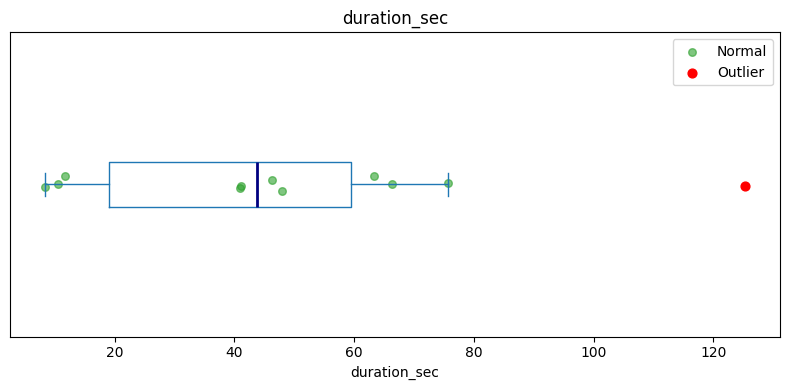

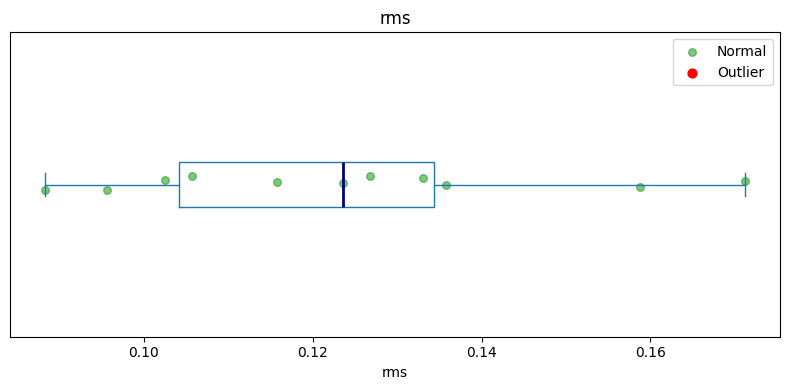

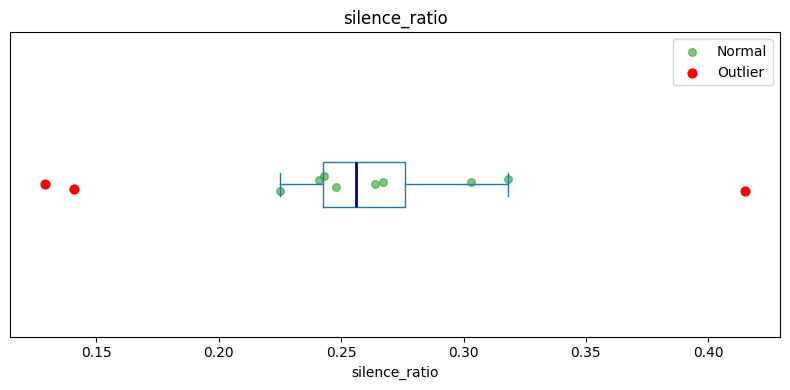

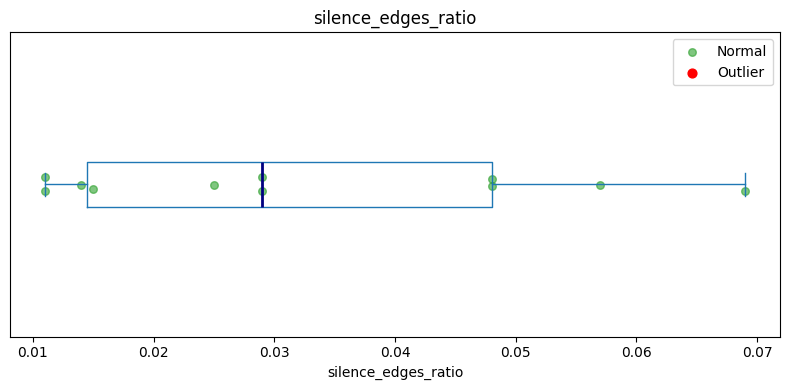

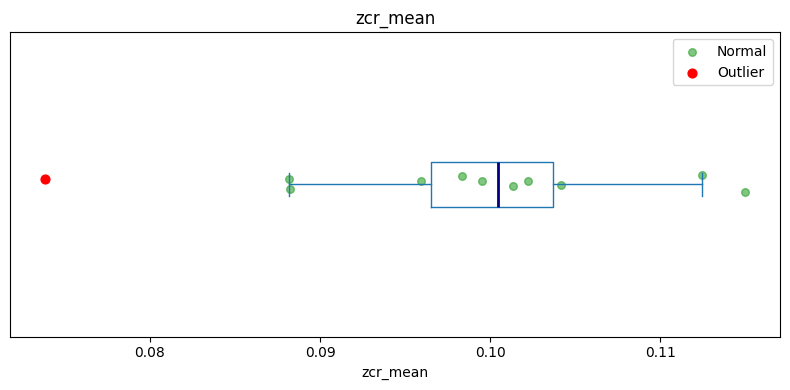

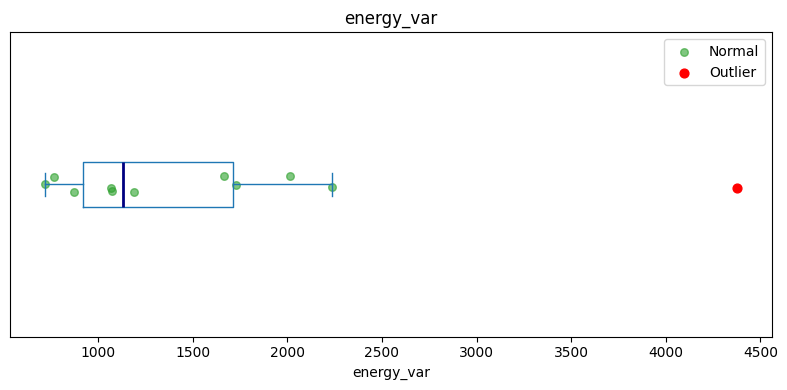

In [174]:
# Lista de métricas a analizar
metrics = ["duration_sec", "rms", "silence_ratio", "silence_edges_ratio", "zcr_mean", "energy_var"]

for metric in metrics:

    data = df_metrics[metric].values

    # Cálculo de outliers (IQR)
    q1 = np.percentile(data, 25)
    q3 = np.percentile(data, 75)
    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    normal_mask = (data >= lower_bound) & (data <= upper_bound)
    outlier_mask = ~normal_mask

    normal_data = data[normal_mask]
    outlier_data = data[outlier_mask]

    plt.figure(figsize=(8, 4))

    # Boxplot sin outliers
    plt.boxplot(
        normal_data,
        vert=False,
        showfliers=False,
        patch_artist=False,
        boxprops=dict(color="tab:blue"),
        whiskerprops=dict(color="tab:blue"),
        capprops=dict(color="tab:blue"),
        medianprops=dict(color="navy", linewidth=2)
    )

    # Puntos normales
    y_normal = np.ones(len(normal_data))
    jitter_normal = np.random.uniform(-0.03, 0.03, size=len(y_normal))

    plt.scatter(
        normal_data,
        y_normal + jitter_normal,
        color="tab:green",
        alpha=0.6,
        s=30,
        label="Normal"
    )

    # Puntos outliers
    y_outliers = np.ones(len(outlier_data))
    jitter_outliers = np.random.uniform(-0.03, 0.03, size=len(y_outliers))

    plt.scatter(
        outlier_data,
        y_outliers + jitter_outliers,
        color="red",
        s=40,
        label="Outlier"
    )

    plt.title(metric)
    plt.xlabel(metric)
    plt.yticks([])
    plt.legend()

    plt.tight_layout()
    plt.show()

#### 5.4.3 Relaciones entre métricas

##### 5.4.3.1 Relación entre RMS y silencio (estructura energética)

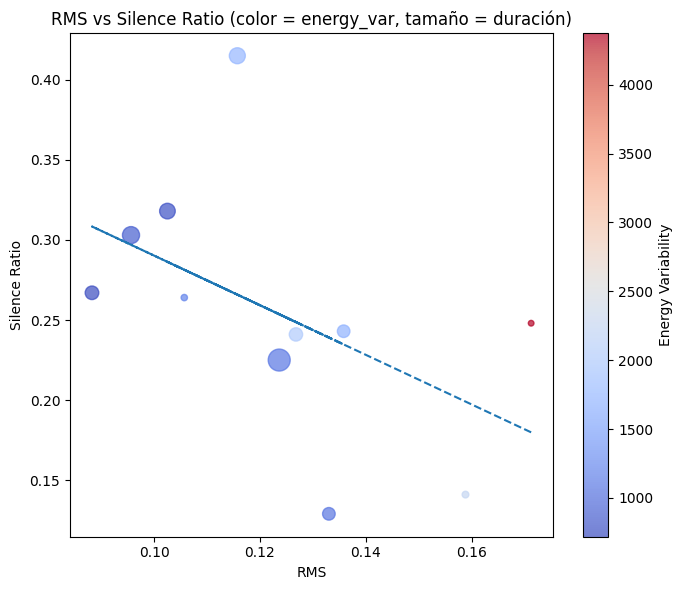

In [ ]:
plt.figure(figsize=(7, 6))

scatter = plt.scatter(
    df_metrics["rms"],
    df_metrics["silence_ratio"],
    c=df_metrics["energy_var"],
    cmap="coolwarm",   # azul → rojo
    s=df_metrics["duration_sec"] * 2,
    alpha=0.7
)

# Línea de tendencia (opcional)
z = np.polyfit(df_metrics["rms"], df_metrics["silence_ratio"], 1)
p = np.poly1d(z)
plt.plot(df_metrics["rms"], p(df_metrics["rms"]), linestyle="--")

plt.xlabel("RMS")
plt.ylabel("Silence Ratio")
plt.title("RMS vs Silence Ratio (color = energy_var, tamaño = duración)")
plt.colorbar(scatter, label="Energy Variability")

plt.tight_layout()
plt.show()

la linea recta

intenta capturar la relación promedio entre RMS y silencio
no pasa por todos los puntos, es un “resumen”
✔️ Cómo interpretarla

En tu gráfico:

la pendiente es negativa
👉 a mayor RMS → menor silencio (ligeramente)

ero:

⚠️ muy importante:

👉 la relación es débil

los puntos están muy dispersos
hay outliers (rojos) que no siguen la tendencia

La línea de tendencia muestra una ligera relación inversa entre el nivel de energía (RMS) y el porcentaje de silencio. No obstante, la elevada dispersión de los datos indica que esta relación es débil y no resulta suficiente para explicar el comportamiento de la señal de forma aislada.

##### 5.4.3.2 Relación entre ZCR y RMS (ruido vs señal estructurada)

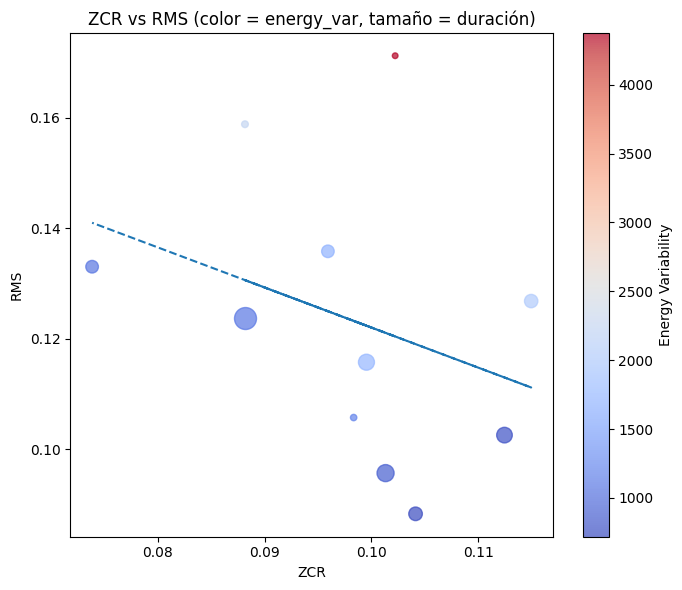

In [177]:
plt.figure(figsize=(7, 6))

scatter = plt.scatter(
    df_metrics["zcr_mean"],
    df_metrics["rms"],
    c=df_metrics["energy_var"],
    cmap="coolwarm",
    s=df_metrics["duration_sec"] * 2,
    alpha=0.7
)

# Línea de tendencia correcta
z = np.polyfit(df_metrics["zcr_mean"], df_metrics["rms"], 1)
p = np.poly1d(z)
plt.plot(df_metrics["zcr_mean"], p(df_metrics["zcr_mean"]), linestyle="--")

plt.xlabel("ZCR")
plt.ylabel("RMS")
plt.title("ZCR vs RMS (color = energy_var, tamaño = duración)")
plt.colorbar(scatter, label="Energy Variability")

plt.tight_layout()
plt.show()

Aquí la línea vuelve a ser lo mismo:

👉 regresión lineal (línea de tendencia) entre ZCR y RMS.

✔️ Qué indica en este gráfico
Pendiente ligeramente negativa
👉 a mayor ZCR → menor RMS (muy leve)
⚠️ Pero lo importante aquí

👉 La relación es aún más débil que en el gráfico anterior

Se ve claramente:

puntos muy dispersos
sin patrón lineal claro
el outlier (rojo) no sigue la tendencia
✔️ Qué puedes interpretar (clave para tu TFM)

Este gráfico te sirve para decir:

No existe una relación clara entre la tasa de cruces por cero (ZCR) y la energía de la señal (RMS), lo que indica que ambas métricas capturan propiedades distintas del audio.

✔️ Insight importante
ZCR → mide “ruido / actividad de alta frecuencia”
RMS → mide energía global

👉 Son dimensiones distintas → no tienen por qué correlacionar

✔️ Lo más valioso del gráfico

No es la línea.

👉 Es esto:

el punto rojo (outlier) destaca por energy_var
no por su posición en ZCR o RMS
🎯 Conclusión clara
✔ La línea es regresión lineal
✔ No hay relación significativa
✔ RMS y ZCR no explican el outlier
✔ energy_var es la métrica clave
🔴 Recomendación (muy importante)

En este gráfico:

👉 yo eliminaría la línea de tendencia

porque:

no aporta información
puede inducir a pensar que hay relación
ensucia la interpretación
✔️ Frase potente para tu memoria

La ausencia de una relación clara entre ZCR y RMS refuerza la necesidad de considerar métricas adicionales, como la variabilidad energética, para la detección de comportamientos anómalos en la señal.

#### 5.4.4 Identificación de casos extremos

In [178]:
cols = ["audio_id", "duration_sec", "rms", "silence_ratio", "silence_edges_ratio", "zcr_mean", "energy_var"]

# Selección de audios con mayor porcentaje de silencio global
high_silence = df_metrics.sort_values("silence_ratio", ascending=False).head(5)[cols]

# Selección de audios con menor energía (RMS bajo)
low_rms = df_metrics.sort_values("rms", ascending=True).head(5)[cols]

# Selección de audios con mayor ZCR (potencial ruido)
high_zcr = df_metrics.sort_values("zcr_mean", ascending=False).head(5)[cols]

# Selección de audios con mayor variabilidad energética
high_energy = df_metrics.sort_values("energy_var", ascending=False).head(5)[cols]

# Selección de audios con mayor silencio en extremos (NUEVO)
high_silence_edges = df_metrics.sort_values("silence_edges_ratio", ascending=False).head(5)[cols]


print("\nAudios con mayor silencio global:")
display(high_silence)

print("\nAudios con mayor silencio en extremos:")
display(high_silence_edges)

print("\nAudios con menor RMS:")
display(low_rms)

print("\nAudios con mayor ZCR:")
display(high_zcr)

print("\nAudios con mayor variabilidad energética:")
display(high_energy)


Audios con mayor silencio global:


,audio_id,duration_sec,rms,silence_ratio,silence_edges_ratio,zcr_mean,energy_var
2,AUDIO-2026-04-21-17-26-57,66.32,0.11573,0.415,0.011,0.09954,1727.792603
4,AUDIO-2026-04-22-11-24-06,63.36,0.10253,0.318,0.048,0.11247,766.692322
7,AUDIO-2026-04-25-10-36-43,75.65,0.09565,0.303,0.011,0.10133,872.353027
6,AUDIO-2026-04-25-10-36-13,47.91,0.08828,0.267,0.029,0.10414,717.976746
3,AUDIO-2026-04-22-11-23-01,10.56,0.10571,0.264,0.048,0.09834,1190.296997



Audios con mayor silencio en extremos:


,audio_id,duration_sec,rms,silence_ratio,silence_edges_ratio,zcr_mean,energy_var
0,AUDIO-2025-09-18-13-34-03,8.36,0.17122,0.248,0.069,0.10223,4376.666992
1,AUDIO-2026-03-12-09-54-36,11.77,0.15882,0.141,0.057,0.08816,2234.810547
3,AUDIO-2026-04-22-11-23-01,10.56,0.10571,0.264,0.048,0.09834,1190.296997
4,AUDIO-2026-04-22-11-24-06,63.36,0.10253,0.318,0.048,0.11247,766.692322
6,AUDIO-2026-04-25-10-36-13,47.91,0.08828,0.267,0.029,0.10414,717.976746



Audios con menor RMS:


,audio_id,duration_sec,rms,silence_ratio,silence_edges_ratio,zcr_mean,energy_var
6,AUDIO-2026-04-25-10-36-13,47.91,0.08828,0.267,0.029,0.10414,717.976746
7,AUDIO-2026-04-25-10-36-43,75.65,0.09565,0.303,0.011,0.10133,872.353027
4,AUDIO-2026-04-22-11-24-06,63.36,0.10253,0.318,0.048,0.11247,766.692322
3,AUDIO-2026-04-22-11-23-01,10.56,0.10571,0.264,0.048,0.09834,1190.296997
2,AUDIO-2026-04-21-17-26-57,66.32,0.11573,0.415,0.011,0.09954,1727.792603



Audios con mayor ZCR:


,audio_id,duration_sec,rms,silence_ratio,silence_edges_ratio,zcr_mean,energy_var
5,AUDIO-2026-04-25-10-35-47,46.25,0.12680,0.241,0.015,0.11497,2016.184204
4,AUDIO-2026-04-22-11-24-06,63.36,0.10253,0.318,0.048,0.11247,766.692322
6,AUDIO-2026-04-25-10-36-13,47.91,0.08828,0.267,0.029,0.10414,717.976746
0,AUDIO-2025-09-18-13-34-03,8.36,0.17122,0.248,0.069,0.10223,4376.666992
7,AUDIO-2026-04-25-10-36-43,75.65,0.09565,0.303,0.011,0.10133,872.353027



Audios con mayor variabilidad energética:


,audio_id,duration_sec,rms,silence_ratio,silence_edges_ratio,zcr_mean,energy_var
0,AUDIO-2025-09-18-13-34-03,8.36,0.17122,0.248,0.069,0.10223,4376.666992
1,AUDIO-2026-03-12-09-54-36,11.77,0.15882,0.141,0.057,0.08816,2234.810547
5,AUDIO-2026-04-25-10-35-47,46.25,0.12680,0.241,0.015,0.11497,2016.184204
2,AUDIO-2026-04-21-17-26-57,66.32,0.11573,0.415,0.011,0.09954,1727.792603
8,AUDIO-2026-04-25-10-37-29,40.87,0.13581,0.243,0.029,0.09593,1667.504517


### 5.5 Identificación de audios problemáticos

Aquí defines:

reglas (umbrales o percentiles)
flag tipo:
is_outlier
needs_vad
needs_processing

#### 5.5.1 Definición de umbrales (basados en percentiles)

In [ ]:
# Cálculo de percentiles para definir umbrales robustos
p_low_rms = df_metrics["rms"].quantile(0.10)
p_high_silence = df_metrics["silence_ratio"].quantile(0.90)
p_high_silence_edges = df_metrics["silence_edges_ratio"].quantile(0.90)
p_high_zcr = df_metrics["zcr_mean"].quantile(0.90)
p_high_energy = df_metrics["energy_var"].quantile(0.90)

print("Umbrales definidos:")
print(f"RMS bajo (P10): {round(p_low_rms, 5)}")
print(f"Silencio global alto (P90): {round(p_high_silence, 3)}")
print(f"Silencio en extremos alto (P90): {round(p_high_silence_edges, 3)}")
print(f"ZCR alto (P90): {round(p_high_zcr, 5)}")
print(f"Energy_var alto (P90): {round(p_high_energy, 2)}")

Umbrales definidos:
RMS bajo (P10): 0.09565
Silencio global alto (P90): 0.318
Silencio en extremos alto (P90): 0.057
ZCR alto (P90): 0.11247
Energy_var alto (P90): 2234.81


#### 5.5.2 Generación de flags

In [181]:
# Flags (detección híbrida: percentiles + límites absolutos)

df_metrics["low_energy"] = (
    (df_metrics["rms"] < p_low_rms) |
    (df_metrics["rms"] < 0.09)   # límite mínimo seguro
)

df_metrics["high_silence"] = (
    (df_metrics["silence_ratio"] > p_high_silence) |
    (df_metrics["silence_ratio"] > 0.30)
)

df_metrics["high_silence_edges"] = (
    (df_metrics["silence_edges_ratio"] > p_high_silence_edges) |
    (df_metrics["silence_edges_ratio"] > 0.18)
)

df_metrics["high_zcr"] = (
    (df_metrics["zcr_mean"] > p_high_zcr) |
    (df_metrics["zcr_mean"] > 0.11)
)

df_metrics["high_energy_var"] = (
    (df_metrics["energy_var"] > p_high_energy) |
    (df_metrics["energy_var"] > 2000)   # umbral empírico inicial
)


# Decisiones de procesamiento

# 1. NO procesar (prioridad absoluta)
df_metrics["skip_processing"] = df_metrics["high_energy_var"]

# 2. High-pass (filtro base)
df_metrics["apply_highpass"] = ~df_metrics["high_energy_var"]

# 3. Denoise (ruido claro y señal estable)
df_metrics["apply_denoise"] = (
    df_metrics["high_zcr"] &
    ~df_metrics["low_energy"] &
    ~df_metrics["high_energy_var"]
)

# 4. Normalización (señal débil sin ruido)
df_metrics["apply_rms"] = (
    df_metrics["low_energy"] &
    ~df_metrics["high_zcr"] &
    ~df_metrics["high_energy_var"]
)

# 5. VAD (definir primero)
df_metrics["needs_vad"] = (
    df_metrics["high_silence"] &
    (df_metrics["duration_sec"] > 30)
)

# 6. Trimming (ya puede usar needs_vad)
df_metrics["apply_trim"] = (
    df_metrics["high_silence_edges"] &
    ~df_metrics["needs_vad"] &
    ~df_metrics["high_energy_var"]
)

#### 5.5.3 Resumen de resultados

In [182]:
print("\n=== Resumen de decisiones de procesamiento ===")

print(f"Total audios: {len(df_metrics)}")

print(f"Baseline (sin procesar): {df_metrics['skip_processing'].sum()}")
print(f"High-pass (filtro base): {df_metrics['apply_highpass'].sum()}")
print(f"Denoise (ruido): {df_metrics['apply_denoise'].sum()}")
print(f"Normalización RMS (baja energía): {df_metrics['apply_rms'].sum()}")
print(f"Trimming (silencio en extremos): {df_metrics['apply_trim'].sum()}")
print(f"VAD (silencio estructural): {df_metrics['needs_vad'].sum()}")


print("\nEjemplo de decisiones por audio:")
display(df_metrics[
    [
        "audio_id",
        "low_energy",
        "high_silence",
        "high_silence_edges",
        "high_zcr",
        "high_energy_var",
        "skip_processing",
        "apply_highpass",
        "apply_denoise",
        "apply_rms",
        "apply_trim",
        "needs_vad"
    ]
].head(10))


=== Resumen de decisiones de procesamiento ===
Total audios: 11
Baseline (sin procesar): 3
High-pass (filtro base): 8
Denoise (ruido): 1
Normalización RMS (baja energía): 1
Trimming (silencio en extremos): 0
VAD (silencio estructural): 3

Ejemplo de decisiones por audio:


,audio_id,low_energy,high_silence,high_silence_edges,high_zcr,high_energy_var,skip_processing,apply_highpass,apply_denoise,apply_rms,apply_trim,needs_vad
0,AUDIO-2025-09-18-13-34-03,False,False,True,False,True,True,False,False,False,False,False
1,AUDIO-2026-03-12-09-54-36,False,False,False,False,True,True,False,False,False,False,False
2,AUDIO-2026-04-21-17-26-57,False,True,False,False,False,False,True,False,False,False,True
3,AUDIO-2026-04-22-11-23-01,False,False,False,False,False,False,True,False,False,False,False
4,AUDIO-2026-04-22-11-24-06,False,True,False,True,False,False,True,True,False,False,True
5,AUDIO-2026-04-25-10-35-47,False,False,False,True,True,True,False,False,False,False,False
6,AUDIO-2026-04-25-10-36-13,True,False,False,False,False,False,True,False,True,False,False
7,AUDIO-2026-04-25-10-36-43,False,True,False,False,False,False,True,False,False,False,True
8,AUDIO-2026-04-25-10-37-29,False,False,False,False,False,False,True,False,False,False,False
9,AUDIO-2026-04-25-10-37-58,False,False,False,False,False,False,True,False,False,False,False




Explicamos cómo usas esos flags y qué pipeline sigue cada audio.

## 6. Optimización de la señal para reconocimiento del habla

En esta sección se abordan distintas técnicas de procesamiento de señal orientadas a mejorar la calidad de los audios para su uso en sistemas de reconocimiento automático del habla (*ASR*).

A diferencia de la etapa de estandarización, centrada en garantizar la consistencia del formato de entrada, en esta fase se analiza el efecto de diversas transformaciones sobre la señal con el objetivo de mejorar su inteligibilidad y su robustez frente a condiciones adversas propias de entornos no controlados, como la presencia de ruido de fondo o la variabilidad en la intensidad.

El objetivo de este bloque es evaluar de forma controlada el impacto de cada técnica sobre la señal, identificando aquellas transformaciones que aportan mejoras reales sin introducir efectos no deseados.

Dado que estas transformaciones pueden tener efectos tanto positivos como negativos sobre el rendimiento del sistema, se adopta un enfoque experimental basado en la comparación sistemática de distintas configuraciones respecto a una señal de referencia (*baseline*), correspondiente a los audios estandarizados sin procesamiento adicional.

### 6.2 Eliminación de regiones no informativas en los extremos del audio

En este apartado se aplica un recorte de silencios en los extremos de la señal de audio, con el objetivo de eliminar segmentos iniciales y finales que no contienen información relevante.

El objetivo de esta operación es reducir la duración del audio y mejorar la eficiencia del procesamiento posterior, evitando que el sistema *ASR* procese tramos sin contenido útil.

El recorte se realiza en función de un umbral de energía definido mediante el parámetro `top_db`, que determina el nivel a partir del cual una región de la señal se considera silencio.

Dado que la elección de este umbral influye directamente en la cantidad de señal eliminada, se evalúan distintos valores de `top_db` con el fin de analizar su impacto sobre la señal y seleccionar la configuración más adecuada.

#### 6.2.1 *Trimming*

In [189]:
# Aplicación de trim SOLO a audios que cumplen condición

# Distintos valores de top_db
top_db_values = [20, 30, 40]

trim_results = {}

# Selección de audios donde tiene sentido aplicar trimming
selected_ids = set(df_metrics[df_metrics["apply_trim"]]["audio_id"])

# Control: si no hay audios, no ejecutar
if len(selected_ids) == 0:
    print("No hay audios candidatos a aplicar trimming.")

else:

    for top_db in top_db_values:

        trim_dataset = []

        for item in baseline_dataset:

            # Filtrado por flag → solo audios relevantes
            if item["audio_id"] not in selected_ids:
                continue

            y = item["y"]
            sr = item["sr"]

            # Aplicación de trim: eliminación de silencios en extremos
            y_trim, _ = librosa.effects.trim(y, top_db=top_db)

            trim_dataset.append({
                "audio_id": item["audio_id"],
                "y": y_trim,
                "sr": sr
            })

        # Se agrupan los resultados por configuración
        trim_results[top_db] = trim_dataset

        print(f"Trim aplicado con top_db = {top_db} sobre {len(trim_dataset)} audios")

No hay audios candidatos a aplicar trimming.


MODIFICAR O ELIMINAR
En este bloque se aplica la operación de *trim* utilizando distintos valores del parámetro `top_db`, que define el umbral de energía relativo a partir del cual una región de la señal se considera silencio.

El objetivo de este proceso es generar distintas versiones recortadas de la señal que permitan analizar el efecto del umbral sobre la duración efectiva del audio y la preservación del contenido relevante.

Las señales resultantes se almacenan en una estructura organizada por valor de `top_db`, facilitando su posterior análisis y la selección de la configuración más adecuada.

##### 6.2.1.1 Evaluación del *trim*
## retocar intro


En este subapartado se evalúa el impacto de la operación de *trim* sobre la señal de audio, analizando cómo distintos valores del parámetro `top_db` afectan a la duración y a la estructura temporal de la señal.

El objetivo de este análisis es identificar el umbral más adecuado que permita eliminar silencios no relevantes, preservando al mismo tiempo la integridad del contenido de voz y evitando la pérdida de información útil en los extremos del audio.

###### 6.2.1.1.1 Métricas (cuantitativo)

In [195]:
# Selección de muestra SOLO dentro de los audios con trimming

# Control: si no hay audios, no ejecutar
if len(selected_ids) == 0:
    print("No hay audios para analizar trimming.")

else:

    # Selección de una muestra de audios para análisis comparativo
    NUM_SAMPLES = 2

    # Fijamos semilla para garantizar reproducibilidad
    random.seed(42)

    # Lista de IDs válidos
    valid_ids = list(selected_ids)

    # Seleccionamos IDs aleatorios
    sampled_ids = random.sample(valid_ids, min(NUM_SAMPLES, len(valid_ids)))

    # Frecuencia de muestreo asumida tras estandarización
    sr = 16000

    # Lista para almacenar métricas de cada configuración
    rows = []

    # Iteramos sobre cada audio seleccionado
    for audio_id in sampled_ids:

        # Señal original
        base = next(item["y"] for item in baseline_dataset if item["audio_id"] == audio_id)

        # Cálculo de duración original
        duration_base = len(base) / sr

        # Evaluación de cada configuración de trimming
        for top_db in top_db_values:

            # Buscar señal trim correspondiente
            y_trim = next(item["y"] for item in trim_results[top_db] if item["audio_id"] == audio_id)

            # Duración tras trimming
            duration_trim = len(y_trim) / sr

            # Porcentaje de reducción
            reduction = (1 - len(y_trim) / len(base)) * 100

            # Registro
            rows.append({
                "audio_id": audio_id,
                "config": f"Trim top_db={top_db}",
                "duration_base": round(duration_base, 2),
                "duration_trim": round(duration_trim, 2),
                "reduction_%": round(reduction, 2)
            })

    # Conversión a DataFrame
    df_metrics_trim = pd.DataFrame(rows)

    # Visualización
    display(df_metrics_trim)

No hay audios para analizar trimming.


Aqui el análisis

###### 6.2.1.1.2 Señal (visual)

In [197]:
# Comparación visual entre señal original y versiones con trimming

if len(selected_ids) == 0:
    print("No hay audios para visualización de trimming.")

else:

    for audio_id in sampled_ids:

        # Señal base
        base = next(item["y"] for item in baseline_dataset if item["audio_id"] == audio_id)

        # Señales recortadas
        trims = {
            f"Trim top_db={top_db}":
            next(item["y"] for item in trim_results[top_db] if item["audio_id"] == audio_id)
            for top_db in top_db_values
        }

        signals = {
            "Baseline": base,
            **trims
        }

        plt.figure(figsize=(12, 8))
        plt.suptitle(f"Audio - {audio_id}", fontsize=16)

        max_time = len(base) / sr
        y_max = max(np.max(np.abs(y)) for y in signals.values())

        colors = plt.cm.tab10(range(len(signals)))

        for i, ((label, y), color) in enumerate(zip(signals.items(), colors), start=1):

            time_axis = np.arange(len(y)) / sr

            plt.subplot(len(signals), 1, i)
            plt.plot(time_axis, y, color=color)

            plt.xlim(0, max_time)
            plt.ylim(-y_max, y_max)

            plt.axhline(0, linestyle='--', linewidth=0.5)
            plt.title(label)
            plt.xlabel("Tiempo (s)")

        plt.tight_layout(rect=[0, 0, 1, 0.96])
        plt.show()

No hay audios para visualización de trimming.


Aqui el análisis

###### 6.2.1.1.3 Escucha (cualitativo)

In [198]:
# Comparación visual entre señal original y versiones con trimming

# Control: si no hay audios, no ejecutar
if len(selected_ids) == 0:
    print("No hay audios para visualización de trimming.")

else:

    for audio_id in sampled_ids:

        # Señal base (sin trimming)
        base = next(item["y"] for item in baseline_dataset if item["audio_id"] == audio_id)

        # Generación de señales recortadas
        trims = {
            f"Trim top_db={top_db}":
            next(item["y"] for item in trim_results[top_db] if item["audio_id"] == audio_id)
            for top_db in top_db_values
        }

        # Diccionario final
        signals = {
            "Baseline": base,
            **trims
        }

        # Figura
        plt.figure(figsize=(12, 8))
        plt.suptitle(f"Audio - {audio_id}", fontsize=16)

        # Límites comunes
        max_time = len(base) / sr
        y_max = max(np.max(np.abs(y)) for y in signals.values())

        # Colores
        colors = plt.cm.tab10(range(len(signals)))

        # Subplots
        for i, ((label, y), color) in enumerate(zip(signals.items(), colors), start=1):

            time_axis = np.arange(len(y)) / sr

            plt.subplot(len(signals), 1, i)
            plt.plot(time_axis, y, color=color)

            plt.xlim(0, max_time)
            plt.ylim(-y_max, y_max)

            plt.axhline(0, linestyle='--', linewidth=0.5)
            plt.title(label)
            plt.xlabel("Tiempo (s)")

        plt.tight_layout(rect=[0, 0, 1, 0.96])
        plt.show()

No hay audios para visualización de trimming.


Aqui el análisis

##### 6.2.1.2 Conclusiones del *trim*

REESCRIBIR CON LOS VALORES REALES. 20dB es el mejor en este caso
A partir de la comparación realizada, se observa que valores bajos de `top_db` producen un recorte limitado, manteniendo gran parte de los silencios originales. Por el contrario, valores elevados generan un recorte más agresivo, eliminando segmentos de baja energía que pueden incluir tanto silencios como partes débiles de la señal de voz.

En términos de duración, el efecto del *trim* es directamente proporcional al valor de `top_db`, reduciendo progresivamente la longitud del audio a medida que aumenta el umbral.

El análisis visual permite identificar la eliminación de regiones planas en los extremos de la señal, mientras que la evaluación auditiva resulta clave para detectar posibles pérdidas de información relevante.

En base a estos resultados, se selecciona el valor de `top_db` que logra un equilibrio entre reducción de silencios y preservación de la señal de voz, evitando un recorte excesivo que pueda afectar negativamente al contenido del audio.

#### 6.2.2 *Trim* + *Padding*
## retocar intro

En este apartado se evalúa la incorporación de un margen de silencio artificial en los extremos de la señal tras la aplicación del *trim*.

El objetivo de esta operación es evitar cortes bruscos al inicio y al final del audio, proporcionando un contexto temporal adicional que puede resultar beneficioso para el sistema *ASR*, especialmente en la correcta delimitación de los segmentos de voz.

In [ ]:
# Aplicación de padding tras trim

# Configuración del pipeline
SELECTED_TOP_DB = 20
PADDING_MS = 300
TARGET_SR = 16000

# Conversión a muestras
padding_samples = int((PADDING_MS / 1000) * TARGET_SR)

trim_pad_dataset = []

processed_count = 0

for item in trim_results[SELECTED_TOP_DB]:

    y = item["y"]
    sr = item["sr"]

    # Generación de silencio (padding)
    pad = np.zeros(padding_samples)

    # Aplicación de padding al inicio y al final
    y_pad = np.concatenate([pad, y, pad])

    trim_pad_dataset.append({
        "audio_id": item["audio_id"],
        "y": y_pad,
        "sr": sr
    })

    processed_count += 1

# Resumen
print("=== Trim + Padding ===")
print(f"Audios procesados: {processed_count}")

En este bloque se añade un margen de silencio artificial al inicio y al final de la señal previamente recortada mediante *trim*. El padding se genera como una señal nula y se concatena a ambos extremos del audio, ampliando el contexto temporal sin alterar el contenido interno de la señal.

El objetivo de esta operación es evitar cortes bruscos en los extremos de la señal tras la eliminación de silencios, preservando el contexto acústico necesario para una correcta interpretación por parte del sistema *ASR*.

Se establece un valor de 300 ms de forma empírica, como un compromiso entre la eliminación efectiva de segmentos no informativos y la conservación de suficiente contexto temporal, evitando introducir silencios excesivos que puedan afectar a la eficiencia del procesamiento.

##### 6.2.2.1 Evaluación de *trim* + *padding*

En este subapartado se analiza el impacto de la incorporación de *padding* tras la aplicación de *trim*, comparando la señal resultante con las versiones previas (*baseline* y señal recortada).

El objetivo de este análisis es evaluar si la inclusión de este margen de silencio mejora la estabilidad en los extremos de la señal y preserva adecuadamente el contexto acústico, sin introducir efectos no deseados ni incrementar de forma significativa la duración del audio.

###### 6.2.2.1.1 Métricas (cuantitativo)

In [ ]:
# Selección de una muestra de audios para comparar baseline, trimming y padding

NUM_SAMPLES = 2

# Semilla para reproducibilidad
random.seed(42)

# Selección de índices del dataset
indices = random.sample(range(len(baseline_dataset)), NUM_SAMPLES)

rows = []

for idx in indices:

    # Señales en cada etapa
    base = baseline_dataset[idx]["y"]
    trim = trim_results[SELECTED_TOP_DB][idx]["y"]
    trim_pad = trim_pad_dataset[idx]["y"]

    # Frecuencia de muestreo (extraída del dataset, no hardcodeada)
    sr = baseline_dataset[idx]["sr"]

    # Duración baseline
    duration_base = len(base) / sr

    # Duración tras trimming y reducción
    duration_trim = len(trim) / sr
    reduction_trim = (1 - len(trim) / len(base)) * 100

    # Duración tras trimming + padding y variación respecto a baseline
    duration_trim_pad = len(trim_pad) / sr
    variation_pad = (len(trim_pad) - len(base)) / len(base) * 100

    # Registro de resultados
    rows.append({
        "audio_id": idx,
        "baseline_sec": round(duration_base, 2),
        "trim_sec": round(duration_trim, 2),
        "trim_reduction_%": round(reduction_trim, 2),
        "trim_pad_sec": round(duration_trim_pad, 2),
        "pad_variation_%": round(variation_pad, 2)
    })

# Conversión a DataFrame
df_metrics = pd.DataFrame(rows)

# Visualización
display(df_metrics)

Aqui el análisis

###### 6.2.2.1.2 Señal (visual)

In [ ]:
# Comparación visual entre señal original, trimming y trimming + padding

for idx in indices:

    # Señales en cada etapa del pipeline
    base = baseline_dataset[idx]["y"]
    trim = trim_results[SELECTED_TOP_DB][idx]["y"]
    trim_pad = trim_pad_dataset[idx]["y"]

    # Diccionario de señales a representar
    signals = {
        "Baseline": base,
        f"Trim top_db={SELECTED_TOP_DB}": trim,
        "Trim + Padding": trim_pad
    }

    # Inicialización de la figura
    plt.figure(figsize=(12, 6))
    plt.suptitle(f"Audio {idx}", fontsize=16)

    # Definición de límites comunes para facilitar comparación
    max_len = len(base)
    y_max = max(np.max(np.abs(y)) for y in signals.values())

    # Número de señales a representar
    n_plots = len(signals)

    # Selección de colores
    colors = plt.cm.tab10(range(n_plots))

    # Representación de cada señal en subplots alineados
    for i, ((label, y), color) in enumerate(zip(signals.items(), colors), start=1):
        plt.subplot(n_plots, 1, i)
        plt.plot(y, color=color)
        plt.xlim(0, max_len)
        plt.ylim(-y_max, y_max)
        plt.axhline(0, linestyle='--', linewidth=0.5)
        plt.title(label)

    # Ajuste del layout para evitar solapamientos
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

Aqui el análisis

###### 6.2.2.1.3 Escucha (cualitativo)

In [ ]:
# Reproducción de señales en distintas etapas del pipeline (baseline, trim, trim + padding)

for idx in indices:

    # Señales en cada etapa
    base = baseline_dataset[idx]["y"]
    trim = trim_results[SELECTED_TOP_DB][idx]["y"]
    trim_pad = trim_pad_dataset[idx]["y"]

    # Frecuencia de muestreo real del audio
    sr = baseline_dataset[idx]["sr"]

    # Diccionario de señales a reproducir
    signals = {
        "Baseline": base,
        f"Trim top_db={SELECTED_TOP_DB}": trim,
        "Trim + Padding": trim_pad
    }

    # Duración de la señal original
    duration_base = len(base) / sr

    print(f"\n===================================")
    print(f"Audio {idx} (duración original: {round(duration_base, 2)}s)")
    print(f"===================================\n")

    # Reproducción de cada versión con su duración
    for label, y in signals.items():
        duration = len(y) / sr
        print(f"{label} (duración: {round(duration, 2)}s)")
        display(Audio(y, rate=sr))

Aqui el análisis

##### 6.2.2.2 Conclusiones del *trim* + *padding*

REESCRIBIR CON LOS VALORES REALES.

Propuesta de redacción provisional

A partir de los resultados obtenidos, se observa que la incorporación de *padding* tras la aplicación de *trim* puede tener efectos distintos en función de la cantidad de silencio presente en el audio original.

En aquellos casos en los que el recorte elimina una cantidad significativa de silencio, la adición de *padding* puede aumentar ligeramente la duración total de la señal respecto al *baseline*. Por el contrario, en audios con menor presencia de silencios, la duración resultante tras aplicar *trim* y *padding* se mantiene cercana a la original, al no producirse una reducción significativa en la fase de recorte.

Estos resultados sugieren que el impacto del *padding* está condicionado por las características específicas de cada audio, por lo que será necesario validar este comportamiento sobre un conjunto de datos más amplio para determinar su efecto real en el rendimiento del sistema *ASR*.



#### 6.2.3 Conclusiones generales de la eliminación de regiones no informativas

EL RESULTADO ES BUENO PORQUE ACORTAMOS AUDIO Y AÑADIMOS LOS 300MS DE PADDING NECESARIO PARA EL ASR. ALGUNO AUDIOS SE QUEDAN IGUAL, PERO LA MAYORIA REDUCE EL TAMAÑO LEVEMENTE. PONER VENTAJAS.

### 6.3 Filtrado de la señal

En este apartado se analizan distintas técnicas de filtrado orientadas a mejorar la calidad de la señal en entornos ruidosos.

El objetivo de esta etapa es reducir el ruido presente en la señal sin degradar el contenido de voz, evaluando el impacto de distintas estrategias de filtrado sobre la inteligibilidad del audio y su adecuación para sistemas ASR.

#### 6.3.1 Reducción de ruido (*Denoise*)

In [ ]:
# Evaluación del impacto de distintos niveles de reducción de ruido (denoise)

# Valores de intensidad de denoise a evaluar
denoise_levels = [0.5, 0.7, 0.9]

# Diccionario para almacenar los resultados por configuración
denoise_results = {}

# Iteramos sobre cada nivel de denoise
for level in denoise_levels:

    denoise_dataset = []

    # Aplicamos denoise a cada audio del dataset
    for item in trim_pad_dataset:

        y = item["y"]
        sr = item["sr"]

        try:
            # Aplicación de reducción de ruido
            y_denoised = nr.reduce_noise(
                y=y,
                sr=sr,
                prop_decrease=level
            )

            denoise_dataset.append({
                "audio_id": item["audio_id"],
                "y": y_denoised,
                "sr": sr
            })

        except Exception as e:
            print(f"Error en denoise (audio {item['audio_id']}): {e}")

    # Almacenamos resultados para este nivel
    denoise_results[level] = denoise_dataset

    print(f"Denoise aplicado con prop_decrease = {level}")

En este bloque se evalúa el efecto de distintos niveles de reducción de ruido mediante la librería *noisereduce*, utilizando el parámetro `prop_decrease` para controlar la intensidad del filtrado aplicado sobre la señal.

El objetivo es generar distintas versiones de la señal con diferentes grados de atenuación del ruido, permitiendo analizar el impacto de cada configuración sobre la calidad e inteligibilidad del audio.

Las señales resultantes se almacenan en una estructura indexada por nivel de reducción, facilitando su posterior comparación y la selección del valor más adecuado.

##### 6.3.1.1 Evaluación de *denoise*

intro aqui

###### 6.3.1.1.1 Métricas (cuantitativo)

In [ ]:
# Selección de una muestra de audios para evaluar el impacto del denoise sobre la energía de la señal
NUM_SAMPLES = 2

# Fijamos semilla para reproducibilidad
random.seed(42)

# Seleccionamos índices del dataset tras trim + padding
indices = random.sample(range(len(trim_pad_dataset)), NUM_SAMPLES)

rows = []

for idx in indices:

    # Señal base (tras trim + padding, antes de denoise)
    base = trim_pad_dataset[idx]["y"]

    # Cálculo de energía RMS de referencia
    rms_base = np.sqrt(np.mean(base**2))

    for level in denoise_levels:

        # Señal tras aplicar denoise
        y = denoise_results[level][idx]["y"]

        # Energía RMS tras denoise
        rms = np.sqrt(np.mean(y**2))

        # Variación relativa de energía (controlando división por cero)
        if rms_base > 0:
            variation = (rms - rms_base) / rms_base * 100
        else:
            variation = 0.0

        # Registro de resultados
        rows.append({
            "audio_id": idx,
            "config": f"denoise_{level}",
            "rms_baseline": round(rms_base, 4),
            "rms": round(rms, 4),
            "variation_energy_%": round(variation, 2)
        })

# Conversión a DataFrame
df_metrics = pd.DataFrame(rows)

# Visualización
display(df_metrics)

Aqui el análisis

###### 6.3.1.1.2 Señal (visual)

In [ ]:
# Comparación visual del impacto del denoise sobre la señal

for idx in indices:

    # Señal base (tras trim + padding)
    base = trim_pad_dataset[idx]["y"]
    sr = trim_pad_dataset[idx]["sr"]

    # Generación de señales con distintos niveles de denoise
    denoises = {
        f"Denoise {level}": denoise_results[level][idx]["y"]
        for level in denoise_levels
    }

    # Diccionario de señales a representar
    signals = {
        "Baseline (trim + padding)": base,
        **denoises
    }

    # Inicialización de la figura
    plt.figure(figsize=(12, 8))
    plt.suptitle(f"Audio {idx}", fontsize=16)

    # Límites comunes para comparación correcta
    max_len = len(base)
    y_max = max(np.max(np.abs(y)) for y in signals.values())

    # Configuración de subplots
    n_plots = len(signals)
    colors = plt.cm.tab10(range(n_plots))

    # Representación de cada señal
    for i, ((label, y), color) in enumerate(zip(signals.items(), colors), start=1):
        plt.subplot(n_plots, 1, i)
        plt.plot(y, color=color)
        plt.xlim(0, max_len)
        plt.ylim(-y_max, y_max)
        plt.axhline(0, linestyle='--', linewidth=0.5)
        plt.title(label)

    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

Aqui el análisis

###### 6.3.1.1.3 Escucha (cualitativo)

In [ ]:
# Reproducción de señales para evaluación cualitativa del denoise

for idx in indices:

    # Señal base
    base = trim_pad_dataset[idx]["y"]
    sr = trim_pad_dataset[idx]["sr"]

    # Generación de señales con denoise
    denoises = {
        f"Denoise {level}": denoise_results[level][idx]["y"]
        for level in denoise_levels
    }

    # Diccionario de señales a reproducir
    signals = {
        "Baseline (trim + padding)": base,
        **denoises
    }

    print(f"\n========================")
    print(f"Audio {idx}")
    print(f"========================\n")

    # Reproducción de cada señal
    for label, y in signals.items():
        duration = len(y) / sr
        print(f"{label} (duración: {round(duration, 2)}s)")
        display(Audio(y, rate=sr))

Aqui el análisis

##### 6.3.1.2 Conclusiones de la reducción de ruido

Análisis de resultados, retocar con audios reales.

Se observa que, a medida que aumenta el nivel de reducción de ruido, disminuye la energía de la señal, lo que se traduce en una reducción de la amplitud y una mayor atenuación de componentes de baja intensidad. Este efecto indica una eliminación progresiva del ruido, aunque en niveles más altos puede afectar también a componentes de la voz.

Los resultados muestran una reducción progresiva de la energía de la señal a medida que aumenta el nivel de filtrado, lo que indica una mayor atenuación de componentes presentes en el audio.

En particular, el nivel 0.5 presenta una reducción moderada, mientras que 0.7 incrementa de forma significativa la eliminación de energía manteniendo una calidad perceptiva adecuada de la señal. Por el contrario, el nivel 0.9, aunque logra una mayor reducción, comienza a introducir degradación audible en la voz, sugiriendo una pérdida de componentes relevantes.

Estos resultados apuntan a que valores intermedios (en torno a 0.7) ofrecen un mejor equilibrio entre reducción de ruido y preservación del contenido de voz, mientras que niveles más agresivos pueden comprometer la inteligibilidad de la señal.

#### 6.3.2 Filtro paso alto (*high-pass*)

En este apartado se aplica un filtro paso alto sobre la señal de audio con el objetivo de atenuar las componentes de baja frecuencia asociadas a ruido de fondo, como viento, vibraciones o ruido de maquinaria.

El análisis se centra en evaluar el impacto de distintos valores de frecuencia de corte sobre la señal, comparando los resultados con la señal de referencia (*baseline*) mediante métricas cuantitativas, visualización y evaluación auditiva.

El objetivo es determinar si la eliminación de estas componentes mejora la calidad de la señal sin afectar de forma significativa al contenido de voz, optimizando su adecuación para sistemas ASR.

In [ ]:
# Evaluación del impacto de distintos cortes de filtro paso alto sobre la señal

# Definición del filtro paso alto (Butterworth de orden 5)
def highpass_filter(y, sr, cutoff):
    b, a = butter(5, cutoff / (sr / 2), btype='high')
    return filtfilt(b, a, y)

# Frecuencias de corte a evaluar
cutoffs = [50, 100, 150, 200]

# Diccionario para almacenar los resultados por configuración
highpass_results = {}

# Aplicación del filtro para cada valor de cutoff
for cutoff in cutoffs:

    hp_dataset = []

    for item in trim_pad_dataset:

        y = item["y"]
        sr = item["sr"]

        try:
            # Aplicación del filtro paso alto
            y_hp = highpass_filter(y, sr, cutoff)

            hp_dataset.append({
                "audio_id": item["audio_id"],
                "y": y_hp,
                "sr": sr
            })

        except Exception as e:
            print(f"Error en high-pass (audio {item['audio_id']}): {e}")

    # Almacenamiento de resultados para este cutoff
    highpass_results[cutoff] = hp_dataset

    print(f"High-pass aplicado con cutoff={cutoff} Hz")

Comentario del código

En este bloque se aplica un filtro paso alto con distintos valores de frecuencia de corte, con el objetivo de eliminar componentes de baja frecuencia asociados a ruido ambiental.

##### 6.3.2.1 Evaluación del filtro paso alto

intro aqui

###### 6.3.2.1.1 Métricas (cuantitativo)

In [ ]:
# Selección de una muestra de audios para analizar el efecto del filtro sobre la energía
NUM_SAMPLES = 2

# Fijamos semilla para garantizar reproducibilidad
random.seed(42)

# Seleccionamos índices del dataset
indices = random.sample(range(len(trim_pad_dataset)), NUM_SAMPLES)

rows = []

for idx in indices:

    # Señal base (tras trim + padding)
    base = trim_pad_dataset[idx]["y"]
    sr = trim_pad_dataset[idx]["sr"]

    # Cálculo de energía RMS de referencia
    rms_base = np.sqrt(np.mean(base**2))

    for cutoff in cutoffs:

        # Señal tras aplicar high-pass
        y = highpass_results[cutoff][idx]["y"]

        # Energía RMS tras filtrado
        rms = np.sqrt(np.mean(y**2))

        # Variación relativa de energía (controlando división por cero)
        if rms_base > 0:
            variation = (1 - rms / rms_base) * 100
        else:
            variation = 0.0

        # Registro de resultados
        rows.append({
            "audio_id": idx,
            "config": f"highpass_{cutoff}",
            "rms_baseline": round(rms_base, 4),
            "rms": round(rms, 4),
            "variation_energy_%": round(variation, 2)
        })

# Conversión a DataFrame para análisis estructurado
df_metrics = pd.DataFrame(rows)

# Visualización de resultados
display(df_metrics)

Aqui el análisis

###### 6.3.2.1.2 Señal (visual)

In [ ]:
# Comparación visual del efecto del filtro paso alto sobre la señal

for idx in indices:

    # Señal base
    base = trim_pad_dataset[idx]["y"]
    sr = trim_pad_dataset[idx]["sr"]

    # Generación de señales filtradas para cada cutoff
    highpasses = {
        f"High-pass {cutoff} Hz": highpass_results[cutoff][idx]["y"]
        for cutoff in cutoffs
    }

    # Diccionario de señales a representar
    signals = {
        "Baseline (trim + padding)": base,
        **highpasses
    }

    # Inicialización de la figura
    plt.figure(figsize=(12, 8))
    plt.suptitle(f"Audio {idx}", fontsize=16)

    # Límites comunes para permitir comparación coherente
    max_len = len(base)
    y_max = max(np.max(np.abs(y)) for y in signals.values())

    # Configuración de subplots
    n_plots = len(signals)
    colors = plt.cm.tab10(range(n_plots))

    # Representación de cada señal
    for i, ((label, y), color) in enumerate(zip(signals.items(), colors), start=1):
        plt.subplot(n_plots, 1, i)
        plt.plot(y, color=color)
        plt.xlim(0, max_len)
        plt.ylim(-y_max, y_max)
        plt.axhline(0, linestyle='--', linewidth=0.5)
        plt.title(label)

    # Ajuste final de la visualización
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

Aqui el análisis

###### 6.3.2.1.3 Escucha (cualitativo)

In [ ]:
# Reproducción de señales para evaluación cualitativa del impacto del filtro paso alto

for idx in indices:

    # Señal base
    base = trim_pad_dataset[idx]["y"]
    sr = trim_pad_dataset[idx]["sr"]

    # Generación de señales filtradas
    highpasses = {
        f"High-pass {cutoff} Hz": highpass_results[cutoff][idx]["y"]
        for cutoff in cutoffs
    }

    # Diccionario de señales a reproducir
    signals = {
        "Baseline (trim + padding)": base,
        **highpasses
    }

    # Información general del audio
    duration_base = len(base) / sr

    print(f"\n========================")
    print(f"Audio {idx} (duración original: {round(duration_base, 2)}s)")
    print(f"========================\n")

    # Reproducción de cada versión
    for label, y in signals.items():
        duration = len(y) / sr
        print(f"{label} (duración: {round(duration, 2)}s)")
        display(Audio(y, rate=sr))

Aqui el análisis

##### 6.3.2.2 Conclusiones del filtro paso alto

Análisis de resultados, retocar con audios reales.

Los resultados muestran que la aplicación de filtros paso alto produce una variación muy limitada en la energía de la señal, lo que indica una baja presencia de ruido de baja frecuencia en los audios analizados.

En este contexto, valores de corte superiores a 150 Hz introducen una reducción adicional de la energía sin un beneficio claro, sugiriendo una posible afectación del contenido de voz. Por ello, se selecciona 100 Hz como configuración más adecuada, al ofrecer un compromiso entre filtrado y preservación de la señal.

El filtrado paso alto permite reducir componentes de baja frecuencia sin alterar significativamente la estructura principal de la señal. No obstante, cortes demasiado elevados pueden afectar a la base de la voz.

#### 6.3.3 Combinación de técnicas de filtrado

En este apartado se realiza una comparación entre distintas estrategias de filtrado aplicadas a la señal de audio, considerando tanto técnicas individuales como su combinación.

El objetivo es evaluar el impacto conjunto de la reducción de ruido (denoise) y el filtrado paso alto (high-pass), analizando si la aplicación combinada de ambas técnicas permite mejorar la calidad de la señal respecto a su uso individual.

Para ello, se seleccionan las configuraciones más adecuadas identificadas en los apartados anteriores, aplicando un nivel de reducción de ruido intermedio (prop_decrease = 0.7) y un filtro paso alto con frecuencia de corte de 100 Hz, con el fin de analizar su comportamiento conjunto sobre la señal.

In [ ]:
# Aplicación combinada de denoise y filtro paso alto sobre la señal

# Configuración seleccionada tras el análisis previo
BEST_DENOISE = 0.7
BEST_HIGHPASS = 100

# Definición del filtro paso alto (Butterworth de orden 5)
def highpass_filter(y, sr, cutoff):
    b, a = butter(5, cutoff / (sr / 2), btype='high')
    return filtfilt(b, a, y)

# Lista para almacenar el resultado del pipeline combinado
combined_dataset = []

# Contadores para control del proceso
processed_count = 0
error_count = 0
error_files = []

# Aplicación secuencial del pipeline: denoise → high-pass
for item in trim_pad_dataset:

    y = item["y"]
    sr = item["sr"]

    try:
        # Paso 1: reducción de ruido
        y_denoise = nr.reduce_noise(y=y, sr=sr, prop_decrease=BEST_DENOISE)

        # Paso 2: eliminación de bajas frecuencias
        y_combined = highpass_filter(y_denoise, sr, cutoff=BEST_HIGHPASS)

        # Almacenamiento del resultado
        combined_dataset.append({
            "audio_id": item["audio_id"],
            "y": y_combined,
            "sr": sr
        })

        processed_count += 1

    except Exception as e:
        # Registro de errores sin detener el pipeline
        error_count += 1
        error_files.append((item["audio_id"], str(e)))

# Resumen del proceso
print("=== Denoise + High-pass ===")
print(f"Procesados correctamente: {processed_count}")
print(f"Errores: {error_count}")

# Muestra de errores (si existen)
if error_count > 0:
    print("\nEjemplos de errores:")
    for audio_id, err in error_files[:5]:
        print(f"- {audio_id}: {err}")

En este bloque se aplica una estrategia de filtrado combinada que integra reducción de ruido (denoise) y filtrado paso alto (high-pass) sobre la señal de audio previamente procesada.

En primer lugar, se aplica un nivel intermedio de reducción de ruido con el objetivo de atenuar componentes no deseadas manteniendo la integridad de la señal. Posteriormente, se aplica un filtro paso alto con frecuencia de corte de 100 Hz, eliminando componentes de baja frecuencia asociadas a ruido de fondo.

La señal resultante se almacena en una nueva estructura, permitiendo su comparación directa con las configuraciones individuales evaluadas previamente.

##### 6.3.3.1 Evaluación de la combinación de técnicas

intro aqui

###### 6.3.3.1.1 Métricas (cuantitativo)

In [ ]:
# Selección de una muestra de audios para comparar el efecto de cada técnica
NUM_SAMPLES = 2

# Fijamos semilla para reproducibilidad
random.seed(42)

# Selección de índices aleatorios del dataset
indices = random.sample(range(len(trim_pad_dataset)), NUM_SAMPLES)

# Lista para almacenar métricas
rows = []

for idx in indices:

    # Señal base (tras trim + padding)
    base = trim_pad_dataset[idx]["y"]
    sr = trim_pad_dataset[idx]["sr"]

    # Cálculo de energía RMS de referencia
    rms_base = np.sqrt(np.mean(base**2))

    # Señales a comparar
    signals = {
        f"denoise_{BEST_DENOISE}": denoise_results[BEST_DENOISE][idx]["y"],
        f"highpass_{BEST_HIGHPASS}": highpass_results[BEST_HIGHPASS][idx]["y"],
        "combined": combined_dataset[idx]["y"]
    }

    for label, y in signals.items():

        # Cálculo de energía RMS
        rms = np.sqrt(np.mean(y**2))

        # Variación relativa de energía respecto al baseline
        if rms_base > 0:
            variation = (rms - rms_base) / rms_base * 100
        else:
            variation = 0.0

        # Registro de resultados
        rows.append({
            "audio_id": idx,
            "config": label,
            "rms_baseline": round(rms_base, 4),
            "rms": round(rms, 4),
            "variation_energy_%": round(variation, 2)
        })

# Conversión a DataFrame
df_metrics = pd.DataFrame(rows)

# Visualización
display(df_metrics)

Aqui el análisis

###### 6.3.3.1.2 Señal (visual)

In [ ]:
# Comparación visual de las distintas configuraciones del pipeline

for idx in indices:

    # Señal base
    base = trim_pad_dataset[idx]["y"]
    sr = trim_pad_dataset[idx]["sr"]

    # Construcción del conjunto de señales a representar
    signals = {
        "Baseline (trim + padding)": base,
        f"Denoise ({BEST_DENOISE})": denoise_results[BEST_DENOISE][idx]["y"],
        f"High-pass ({BEST_HIGHPASS} Hz)": highpass_results[BEST_HIGHPASS][idx]["y"],
        "Combinado (denoise + high-pass)": combined_dataset[idx]["y"]
    }

    # Inicialización de la figura
    plt.figure(figsize=(12, 8))
    plt.suptitle(f"Audio {idx}", fontsize=16)

    # Definición de límites comunes para facilitar la comparación
    max_len = len(base)
    y_max = max(np.max(np.abs(y)) for y in signals.values())

    # Número de señales a representar
    n_plots = len(signals)
    colors = plt.cm.tab10(range(n_plots))

    # Representación de cada señal en subplots alineados
    for i, ((label, y), color) in enumerate(zip(signals.items(), colors), start=1):
        plt.subplot(n_plots, 1, i)
        plt.plot(y, color=color)
        plt.xlim(0, max_len)
        plt.ylim(-y_max, y_max)
        plt.axhline(0, linestyle='--', linewidth=0.5)
        plt.title(label)

    # Ajuste del layout
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

Aqui el análisis

###### 6.3.3.1.3 Escucha (cualitativo)

In [ ]:
# Reproducción de señales para evaluación cualitativa del impacto del pipeline

for idx in indices:

    # Señal base
    base = trim_pad_dataset[idx]["y"]
    sr = trim_pad_dataset[idx]["sr"]

    # Construcción del conjunto de señales a reproducir
    signals = {
        "Baseline (trim + padding)": base,
        f"Denoise ({BEST_DENOISE})": denoise_results[BEST_DENOISE][idx]["y"],
        f"High-pass ({BEST_HIGHPASS} Hz)": highpass_results[BEST_HIGHPASS][idx]["y"],
        "Combinado (denoise + high-pass)": combined_dataset[idx]["y"]
    }

    # Cálculo de duración de la señal original
    duration_base = len(base) / sr

    print(f"\n========================")
    print(f"Audio {idx} (duración original: {round(duration_base, 2)}s)")
    print(f"========================\n")

    # Reproducción de cada versión
    for label, y in signals.items():
        duration = len(y) / sr
        print(f"{label} (duración: {round(duration, 2)}s)")
        display(Audio(y, rate=sr))

Aqui el análisis

##### 6.3.3.2 conclusiones de la combinación de técnicas

Análisis de resultados, retocar con audios reales. se tiene que notar el hightpass o justificar si al final se pone o no. yo creo que si.

Los resultados muestran que la reducción de ruido (*denoise*) constituye el principal factor de mejora en la señal, produciendo una disminución significativa de la energía en ambos audios analizados.

Por el contrario, el filtrado paso alto presenta un impacto prácticamente despreciable en términos de energía global, lo que indica una baja presencia de componentes de baja frecuencia en la señal original.

La aplicación combinada de ambas técnicas no introduce cambios relevantes respecto al uso de *denoise* de forma aislada en términos de energía, si bien puede aportar una ligera mejora cualitativa asociada a la eliminación de componentes de muy baja frecuencia.

Estos resultados sugieren que la contribución del filtro paso alto es secundaria frente a la reducción de ruido, actuando como un refinamiento de la señal más que como un mecanismo principal de mejora.

#### 6.3.4 Conclusiones de filtrado

A partir del análisis realizado, se selecciona la técnica o combinación de técnicas que proporciona la mejor relación entre reducción de ruido y preservación de la señal de voz.

La decisión final se basa en la combinación de métricas cuantitativas, análisis visual y evaluación auditiva, priorizando siempre la inteligibilidad de la señal frente a la eliminación agresiva del ruido.

SE VE UNA MEJORA EN EN ANALISIS CUALITATIVO, PERO CASI IMPREDECIBLE PARA EL OIDO. POR OTRO LADO, SEGUN XXX, EL NOISEREDUCE, AUNQUE ELIMINA RUIDO, DEJA HUECOS EN LAS FRECUENCIAS, QUE AUNQUE PARA EL OIDO HUMANO SUEMA MAS LIPIO, PARA WHISPER, ESOS HUECOS SON INCONSISTENCIAS QUE NO RECONOCE, CONFUNDIENDOLO MAS QUE EL RUIDO ORIGINAL (REFERENCIA AQUI). ESTO SE HA COMPROBADO AL APLICAR WER EN EN NOTEBOOK 2(ENLACE AL NOTEBOOK) Y COMPARAR LOS RESULTADOS.
POR OTRO LADO, EL PASOALTO AYUDA A ELIMINAR FRECUENCIAS BAJAS DE MOTORES Y VIENTO.

### 6.4 Normalización de amplitud (*RMS normalization*)

En este apartado se aplica una normalización de amplitud sobre la señal resultante del pipeline previamente seleccionado, con el objetivo de reducir la variabilidad en el nivel de energía entre distintos audios y proporcionar una entrada más homogénea al sistema de reconocimiento automático del habla (ASR).

Esta etapa se aborda como un refinamiento final de la señal, una vez optimizadas las transformaciones anteriores, permitiendo minimizar problemas asociados a audios con niveles de volumen excesivamente bajos o altos, que pueden afectar negativamente al rendimiento del sistema.

Existen distintos enfoques para la normalización de la señal. Entre los más habituales se encuentran:

* *Peak normalization*, que ajusta la señal para que su valor máximo alcance un umbral determinado
* *RMS normalization*, que ajusta la energía media de la señal, proporcionando un comportamiento más estable desde el punto de vista perceptual

En este trabajo se prioriza el uso de *RMS normalization*, al resultar más robusto en escenarios reales caracterizados por una elevada variabilidad en la dinámica de los audios.

La evaluación de esta técnica se realiza comparando la señal antes y después de la normalización, analizando su impacto desde tres perspectivas complementarias: cuantitativa, mediante métricas basadas en la energía (RMS objetivo frente a RMS real y su desviación); visual, a través de la inspección de la señal; y cualitativa, mediante escucha directa.

El objetivo final es homogenizar el volumen de los audios sin introducir distorsiones ni alterar el contenido relevante de la señal, garantizando así una mejora en la consistencia de la entrada al sistema ASR.

In [ ]:
# Evaluación del impacto de distintos niveles de normalización RMS

# Valores objetivo de energía RMS a analizar
RMS_TARGETS = [0.05, 0.1, 0.2]

# Diccionario para almacenar los resultados por configuración
normalized_results = {}

# Aplicación de normalización para cada nivel objetivo
for target in RMS_TARGETS:

    norm_dataset = []

    for item in combined_dataset:

        y = item["y"]
        sr = item["sr"]

        # Cálculo de energía RMS actual
        rms_current = np.sqrt(np.mean(y**2))

        # Cálculo de la ganancia necesaria (evitando división por cero)
        if rms_current > 0:
            gain = target / rms_current
            y_norm = y * gain
        else:
            y_norm = y

        # Almacenamiento del resultado normalizado
        norm_dataset.append({
            "audio_id": item["audio_id"],
            "y": y_norm,
            "sr": sr,
            "rms_target": target
        })

    normalized_results[target] = norm_dataset

    print(f"Normalización aplicada con RMS objetivo = {target}")

#### 6.4.1 Evaluación de la normalización RMS

intro aqui

##### 6.4.1.1 Métricas (cuantitativo)

In [ ]:
# Selección de muestra para análisis cuantitativo

NUM_SAMPLES = 2
random.seed(42)
indices = random.sample(range(len(combined_dataset)), NUM_SAMPLES)

rows = []

for idx in indices:

    # Señal base sin normalizar
    base = combined_dataset[idx]["y"]
    sr = combined_dataset[idx]["sr"]

    # Métricas de referencia
    rms_base = np.sqrt(np.mean(base**2))
    peak_base = np.max(np.abs(base))

    for target in RMS_TARGETS:

        # Señal normalizada
        y = normalized_results[target][idx]["y"]

        # Cálculo de métricas
        rms = np.sqrt(np.mean(y**2))
        peak = np.max(np.abs(y))

        # Ganancia aplicada respecto a la señal original
        gain = target / rms_base if rms_base > 0 else 0

        # Crest factor: relación entre pico y energía RMS (indicador de dinámica)
        crest = peak / rms if rms > 0 else 0

        # Detección de clipping (valores fuera del rango válido [-1, 1])
        clipping = np.sum(np.abs(y) > 1.0)

        # Registro de resultados
        rows.append({
            "audio_id": idx,
            "config": f"rms_{target}",
            "rms_original": round(rms_base, 4),
            "rms_result": round(rms, 4),
            "gain": round(gain, 2),
            "peak": round(peak, 4),
            "crest_factor": round(crest, 2),
            "clipping_samples": int(clipping)
        })

# Conversión a DataFrame
df_metrics = pd.DataFrame(rows)

# Visualización
display(df_metrics)

Aqui el análisis

de momento nos quedamos con 0.1

##### 6.4.1.2 Señal (visual)

In [ ]:
# Comparación visual del efecto de la normalización RMS

for idx in indices:

    # Señal base
    base = combined_dataset[idx]["y"]
    sr = combined_dataset[idx]["sr"]

    # Generación de señales normalizadas
    norms = {
        f"RMS {target}": normalized_results[target][idx]["y"]
        for target in RMS_TARGETS
    }

    # Señales a representar
    signals = {
        "Pipeline sin normalizar": base,
        **norms
    }

    # Duración de referencia
    duration_base = len(base) / sr

    plt.figure(figsize=(12, 8))
    plt.suptitle(f"Audio {idx} (duración: {round(duration_base, 2)}s)", fontsize=16)

    max_len = len(base)

    # Escala global coherente para comparación
    y_max = max(np.max(np.abs(y)) for y in signals.values())

    n_plots = len(signals)
    colors = plt.cm.tab10(range(n_plots))

    for i, ((label, y), color) in enumerate(zip(signals.items(), colors), start=1):
        plt.subplot(n_plots, 1, i)
        plt.plot(y, color=color)
        plt.xlim(0, max_len)
        plt.ylim(-y_max, y_max)
        plt.axhline(0, linestyle='--', linewidth=0.5)
        plt.title(label)

    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

Aqui el análisis

##### 6.4.1.3 Escucha (cualitativo)

In [ ]:
# Reproducción de señales para evaluación cualitativa

for idx in indices:

    # Señal base
    base = combined_dataset[idx]["y"]
    sr = combined_dataset[idx]["sr"]

    # Generación de señales normalizadas
    norms = {
        f"RMS {target}": normalized_results[target][idx]["y"]
        for target in RMS_TARGETS
    }

    # Señales a reproducir
    signals = {
        "Pipeline sin normalizar": base,
        **norms
    }

    duration_base = len(base) / sr

    print(f"\n========================")
    print(f"Audio {idx} (duración: {round(duration_base, 2)}s)")
    print(f"========================\n")

    for label, y in signals.items():
        duration = len(y) / sr
        print(f"{label} (duración: {round(duration, 2)}s)")
        display(Audio(y, rate=sr))

Aqui el análisis

#### 6.4.2 Conclusiones de la normalización RMS

Análisis de resultados

La normalización permite ajustar el nivel de energía de la señal a un valor objetivo común, reduciendo la variabilidad entre audios.

Desde el punto de vista cuantitativo, se observa que el valor RMS tras la normalización se aproxima al valor objetivo definido, manteniendo una desviación mínima.

El análisis visual confirma que la forma de la señal se conserva, mientras que la evaluación auditiva muestra una mejora en la consistencia del volumen sin introducir distorsiones apreciables.

### 6.5 Segmentación mediante *Voice Activity Detection* (VAD)
PUEDE QUE SEA EL PUNTO 6

La detección de actividad de voz (*Voice Activity Detection*, VAD) permite identificar y eliminar segmentos de baja energía asociados a silencios dentro de la señal de audio. Su aplicación puede contribuir a reducir la duración de los audios y eliminar información no relevante, especialmente en grabaciones de mayor extensión.

No obstante, esta técnica debe emplearse de forma controlada, ya que una segmentación excesiva puede eliminar pausas naturales del habla o fragmentar el discurso, afectando negativamente al contexto lingüístico y, en consecuencia, al rendimiento del sistema de reconocimiento automático del habla (*ASR*).

En este trabajo, el uso de VAD se plantea de forma condicional, aplicándose únicamente en aquellos audios cuya duración supera un umbral predefinido. Esta decisión se fundamenta en que los sistemas ASR modernos, como *Whisper*, ya incorporan mecanismos internos de segmentación, por lo que la aplicación de VAD externo solo resulta potencialmente beneficiosa en audios largos.

Asimismo, se adopta una configuración conservadora que prioriza la preservación de la estructura temporal de la señal, manteniendo pausas breves que pueden corresponder a elementos lingüísticos relevantes.

La evaluación de esta técnica se realiza mediante la comparación entre la señal original del pipeline y la señal segmentada mediante VAD, analizando su impacto desde tres perspectivas: reducción de la duración total del audio, inspección visual de la señal y evaluación perceptiva mediante escucha.

El objetivo es determinar si la aplicación de VAD permite eliminar información irrelevante sin comprometer la integridad del discurso ni la calidad de la transcripción.

#### 6.5.1 VAD basado en energía (*librosa*)

In [ ]:
# Definición de configuraciones VAD basadas en energía (no modelo profundo)
# Se evalúan tres niveles de agresividad para controlar el recorte de silencios

VAD_CONFIGS = {
    "agresivo": {
        "top_db": 20,           # umbral más bajo → detecta más silencio → recorte más agresivo
        "min_silence_ms": 400,  # elimina segmentos muy cortos
        "padding_ms": 200       # añade contexto alrededor de la voz
    },
    "equilibrado": {
        "top_db": 25,
        "min_silence_ms": 300,
        "padding_ms": 150
    },
    "conservador": {
        "top_db": 30,           # umbral más alto → menos eliminación de señal
        "min_silence_ms": 300,
        "padding_ms": 150
    }
}

# Diccionario para almacenar resultados por configuración
vad_results = {}

# Evaluación de cada configuración
for config_name, params in VAD_CONFIGS.items():

    vad_dataset = []

    vad_applied_count = 0
    vad_skipped_count = 0

    # Se asume correspondencia por posición entre señal y metadatos
    for item, meta in zip(normalized_results[0.1], audio_dataset):

        y = item["y"]
        sr = item["sr"]

        # Aplicar segmentación solo a audios largos
        if meta["quality_flag"] == "too_long":

            # Conversión de parámetros a muestras
            min_silence_samples = int((params["min_silence_ms"] / 1000) * sr)
            padding_samples = int((params["padding_ms"] / 1000) * sr)

            # Detección de segmentos con energía significativa
            intervals = librosa.effects.split(
                y,
                top_db=params["top_db"],
                frame_length=2048,
                hop_length=512
            )

            segments = []

            for start, end in intervals:

                # Eliminación de segmentos demasiado cortos
                if (end - start) < min_silence_samples:
                    continue

                # Aplicación de padding para no cortar palabras
                start_pad = max(0, start - padding_samples)
                end_pad = min(len(y), end + padding_samples)

                segment = y[start_pad:end_pad]
                segments.append(segment)

            # Caso crítico: si no hay segmentos válidos, conservar señal original
            if len(segments) == 0:
                segments = [y]

            vad_dataset.append({
                "audio_id": item["audio_id"],
                "segments": segments,
                "sr": sr,
                "vad_applied": True
            })

            vad_applied_count += 1

        else:
            # Audios cortos no se modifican
            vad_dataset.append({
                "audio_id": item["audio_id"],
                "segments": [y],
                "sr": sr,
                "vad_applied": False
            })

            vad_skipped_count += 1

    # Almacenamiento del resultado para esta configuración
    vad_results[config_name] = vad_dataset

    # Resumen del comportamiento
    print(f"\n=== VAD {config_name} ===")
    print(f"Aplicado: {vad_applied_count}")
    print(f"Omitido: {vad_skipped_count}")

Comentario del código

En este bloque se aplica una estrategia de segmentación basada en energía de forma condicional, evaluando previamente la duración de cada audio. Para señales largas, se filtran aquellas muestras cuya amplitud se encuentra por debajo de un umbral definido, eliminando segmentos de baja energía.

La operación se realiza de forma conservadora, evitando eliminar pausas cortas relevantes para la estructura del discurso.

##### 6.5.1.1 Evaluación del VAD basado en energía

Este bloque evalúa el impacto del VAD únicamente en aquellos casos en los que realmente se ha aplicado sobre la señal. En primer lugar, se verifica si existe al menos un audio segmentado mediante VAD dentro del conjunto de resultados. Si se cumple esta condición, se selecciona una muestra aleatoria reproducible de audios y, para cada configuración de VAD, se calculan métricas cuantitativas basadas en la duración: duración original, duración tras segmentación, porcentaje de reducción y número de segmentos generados. El cálculo se realiza exclusivamente sobre los audios en los que el VAD ha sido aplicado, evitando introducir ruido en el análisis. Los resultados se estructuran en un *DataFrame* que permite comparar de forma clara el comportamiento de cada configuración. En caso de no existir audios segmentados, el bloque no ejecuta el análisis y muestra un mensaje informativo, garantizando coherencia metodológica y evitando conclusiones inválidas.

###### 6.5.1.1.1 Métricas (cuantitativo)

In [ ]:
# Número de audios a mostrar
NUM_SAMPLES = 2

# Semilla para reproducibilidad
random.seed(42)

# Construcción del conjunto de índices donde el VAD se aplica en al menos una configuración
candidate_indices = [
    idx for idx in range(len(normalized_results[0.1]))
    if any(vad_results[cfg][idx]["vad_applied"] for cfg in vad_results)
]

# Verificación: si no hay candidatos, se detiene el análisis
if len(candidate_indices) == 0:
    print("No hay audios donde se haya aplicado VAD.")

else:

    # Selección aleatoria SOLO sobre audios válidos
    indices = random.sample(
        candidate_indices,
        min(NUM_SAMPLES, len(candidate_indices))
    )

    rows = []

    # Iteración por configuración de VAD
    for config_name, dataset in vad_results.items():

        # Selección de índices donde VAD se aplica en esta configuración concreta
        config_indices = [
            idx for idx in indices
            if dataset[idx]["vad_applied"]
        ]

        for idx in config_indices:

            # Señal base (sin VAD)
            base = normalized_results[0.1][idx]["y"]
            sr = normalized_results[0.1][idx]["sr"]

            duration_base = len(base) / sr

            # Señal tras VAD
            segments = dataset[idx]["segments"]
            y_vad = np.concatenate(segments)

            duration_vad = len(y_vad) / sr

            # Reducción relativa de duración
            if duration_base > 0:
                reduction = (1 - duration_vad / duration_base) * 100
            else:
                reduction = 0.0

            rows.append({
                "audio_id": idx,
                "config": config_name,
                "duration_original": round(duration_base, 2),
                "duration_vad": round(duration_vad, 2),
                "reduction_%": round(reduction, 2),
                "num_segments": len(segments)
            })

    # Visualización de resultados
    if len(rows) > 0:
        df_vad = pd.DataFrame(rows)
        display(df_vad)
    else:
        print("No hay datos válidos tras el filtrado.")

Análisis de resultados

###### 6.5.1.1.2 Señal (visual)

In [ ]:
# Número de audios a visualizar
NUM_SAMPLES = 2

# Semilla para reproducibilidad
random.seed(42)

# Construcción del conjunto de candidatos:
# audios donde al menos una configuración aplica VAD
candidate_indices = [
    idx for idx in range(len(normalized_results[0.1]))
    if any(vad_results[cfg][idx]["vad_applied"] for cfg in vad_results)
]

# Verificación básica
if len(candidate_indices) == 0:
    print("No hay audios donde se haya aplicado VAD.")

else:

    # Selección aleatoria SOLO sobre audios válidos
    selected_indices = random.sample(
        candidate_indices,
        min(NUM_SAMPLES, len(candidate_indices))
    )

    # Orden fijo de configuraciones para coherencia visual
    VAD_ORDER = ["agresivo", "equilibrado", "conservador"]

    # Iteramos sobre la muestra seleccionada
    for idx in selected_indices:

        # Señal base (sin VAD)
        base = normalized_results[0.1][idx]["y"]
        sr = normalized_results[0.1][idx]["sr"]

        # Selección de configuraciones donde realmente se aplica VAD
        valid_configs = [
            config_name
            for config_name in VAD_ORDER
            if vad_results[config_name][idx]["vad_applied"]
        ]

        # Construcción de señales a visualizar
        signals = [("Original", base)] + [
            (
                f"VAD ({config_name})",
                np.concatenate(vad_results[config_name][idx]["segments"])
            )
            for config_name in valid_configs
        ]

        # Inicialización de figura
        plt.figure(figsize=(12, 6))
        plt.suptitle(f"Audio {idx}", fontsize=14)

        # Escala común para comparación correcta
        max_len = len(base)
        y_max = max(np.max(np.abs(y)) for _, y in signals)

        colors = plt.cm.tab10(range(len(signals)))

        # Representación de cada señal
        for i, ((label, y), color) in enumerate(zip(signals, colors), start=1):
            plt.subplot(len(signals), 1, i)
            plt.plot(y, color=color)
            plt.xlim(0, max_len)
            plt.ylim(-y_max, y_max)
            plt.axhline(0, linestyle='--', linewidth=0.5)
            plt.title(label)

        plt.tight_layout(rect=[0, 0, 1, 0.95])
        plt.show()

Análisis de resultados

###### 6.5.1.1.3 Escucha (cualitativo)

In [ ]:
# Número de audios a reproducir
NUM_SAMPLES = 2

# Semilla para reproducibilidad
random.seed(42)

# Construcción del conjunto de candidatos:
# audios donde al menos una configuración aplica VAD
candidate_indices = [
    idx for idx in range(len(normalized_results[0.1]))
    if any(vad_results[cfg][idx]["vad_applied"] for cfg in vad_results)
]

# Verificación básica
if len(candidate_indices) == 0:
    print("No hay audios donde se haya aplicado VAD.")

else:

    # Selección aleatoria SOLO sobre audios válidos
    selected_indices = random.sample(
        candidate_indices,
        min(NUM_SAMPLES, len(candidate_indices))
    )

    # Iteramos sobre la muestra seleccionada
    for idx in selected_indices:

        # Señal base (sin VAD)
        base = normalized_results[0.1][idx]["y"]
        sr = normalized_results[0.1][idx]["sr"]

        # Selección de configuraciones donde realmente se aplica VAD
        valid_configs = [
            config_name
            for config_name in vad_results
            if vad_results[config_name][idx]["vad_applied"]
        ]

        # Construcción de señales a reproducir
        signals = [("Original", base)] + [
            (
                f"VAD ({config_name})",
                np.concatenate(vad_results[config_name][idx]["segments"])
            )
            for config_name in valid_configs
        ]

        # Separador visual
        print(f"\n========================")
        print(f"Audio {idx}")
        print(f"========================\n")

        # Reproducción de cada señal
        for label, y in signals:
            duration = len(y) / sr
            print(f"{label} (duración: {round(duration, 2)}s)")
            display(Audio(y, rate=sr))

Análisis de resultados
2. Evaluación → problemas detectados:
   - fragmentación
   - pérdida de información
   - sensibilidad al ruido

solo el vad conservador es algo factible, aunque en audios con viento fuerte y ruido fuerte no es 100% efectivo introducionedo fragmentacion y repeticion de silabas

##### 6.5.1.2 Conclusiones del VAD basado en energía

#### 6.5.2 VAD basado en aprendizaje profundo

In [ ]:
# Carga del modelo preentrenado de VAD (Silero basado en PyTorch)
# Este modelo detecta automáticamente regiones con presencia de voz
model = load_silero_vad()

# Dataset de salida con segmentos detectados por VAD
silero_vad_dataset = []

# Contadores para análisis del comportamiento del modelo
vad_applied_count = 0
vad_skipped_count = 0

# Iteración conjunta sobre señales normalizadas y metadatos originales
# Se asume correspondencia posicional entre ambos datasets
for item, meta in zip(normalized_results[0.1], audio_dataset):

    y = item["y"]
    sr = item["sr"]

    # Aplicación de VAD únicamente a audios largos
    # Evita fragmentar innecesariamente audios cortos
    if meta["quality_flag"] == "too_long":

        # Conversión de la señal a tensor de PyTorch (requisito del modelo)
        audio_tensor = torch.from_numpy(y).float()

        # Asegurar señal mono (el modelo espera una única dimensión)
        if audio_tensor.ndim > 1:
            audio_tensor = torch.mean(audio_tensor, dim=0)

        # Normalización del rango dinámico para estabilidad del modelo
        # Se garantiza que los valores estén en [-1, 1]
        if audio_tensor.abs().max() > 1:
            audio_tensor = audio_tensor / audio_tensor.abs().max()

        # Detección de intervalos de voz mediante el modelo Silero
        # Devuelve una lista de timestamps con inicio y fin de cada segmento
        speech_timestamps = get_speech_timestamps(
            audio_tensor,
            model,
            sampling_rate=sr
        )

        # Extracción de segmentos de audio correspondientes a las regiones detectadas
        segments = [
            y[ts["start"]:ts["end"]]
            for ts in speech_timestamps
        ]

        # ⚠️ Caso crítico: si no se detecta ningún segmento, se conserva la señal original
        if len(segments) == 0:
            segments = [y]

        # Almacenamiento del resultado
        silero_vad_dataset.append({
            "audio_id": item["audio_id"],
            "segments": segments,
            "sr": sr,
            "vad_applied": True
        })

        vad_applied_count += 1

    else:
        # En audios cortos no se aplica VAD
        # Se conserva la señal completa como único segmento
        silero_vad_dataset.append({
            "audio_id": item["audio_id"],
            "segments": [y],
            "sr": sr,
            "vad_applied": False
        })

        vad_skipped_count += 1

# Resumen del comportamiento del modelo
print("=== Silero VAD ===")
print(f"Aplicado: {vad_applied_count}")
print(f"Omitido: {vad_skipped_count}")

Comentario del código

En este bloque se aplica una estrategia de segmentación basada en energía de forma condicional, evaluando previamente la duración de cada audio. Para señales largas, se filtran aquellas muestras cuya amplitud se encuentra por debajo de un umbral definido, eliminando segmentos de baja energía.

La operación se realiza de forma conservadora, evitando eliminar pausas cortas relevantes para la estructura del discurso.

##### 6.5.2.1 Evaluación del VAD basado en aprendizaje profundo

Este bloque evalúa el impacto del VAD únicamente en aquellos casos en los que realmente se ha aplicado sobre la señal. En primer lugar, se verifica si existe al menos un audio segmentado mediante VAD dentro del conjunto de resultados. Si se cumple esta condición, se selecciona una muestra aleatoria reproducible de audios y, para cada configuración de VAD, se calculan métricas cuantitativas basadas en la duración: duración original, duración tras segmentación, porcentaje de reducción y número de segmentos generados. El cálculo se realiza exclusivamente sobre los audios en los que el VAD ha sido aplicado, evitando introducir ruido en el análisis. Los resultados se estructuran en un *DataFrame* que permite comparar de forma clara el comportamiento de cada configuración. En caso de no existir audios segmentados, el bloque no ejecuta el análisis y muestra un mensaje informativo, garantizando coherencia metodológica y evitando conclusiones inválidas.

###### 6.5.2.1.1 Métricas (cuantitativo)

In [ ]:
# Número de audios a analizar
NUM_SAMPLES = 2

# Semilla para reproducibilidad
random.seed(42)

# Construcción del conjunto de candidatos:
# audios donde Silero VAD ha sido aplicado
candidate_indices_silero = [
    i for i in range(len(silero_vad_dataset))
    if silero_vad_dataset[i]["vad_applied"]
]

# Verificación básica
if len(candidate_indices_silero) == 0:
    print("No hay audios con Silero VAD aplicado.")

else:

    # Selección aleatoria SOLO sobre audios válidos
    selected_indices = random.sample(
        candidate_indices_silero,
        min(NUM_SAMPLES, len(candidate_indices_silero))
    )

    rows = []

    # Iteración sobre la muestra seleccionada
    for idx in selected_indices:

        # Señal base (sin VAD, tras normalización)
        base = normalized_results[0.1][idx]["y"]
        sr = normalized_results[0.1][idx]["sr"]

        # Duración original
        duration_base = len(base) / sr

        # Señal tras VAD (concatenación de segmentos detectados)
        segments = silero_vad_dataset[idx]["segments"]
        y_vad = np.concatenate(segments)

        duration_vad = len(y_vad) / sr

        # Reducción relativa de duración (controlando división por cero)
        if duration_base > 0:
            reduction = (1 - duration_vad / duration_base) * 100
        else:
            reduction = 0.0

        # Registro de métricas
        rows.append({
            "audio_id": idx,
            "duration_original": round(duration_base, 2),
            "duration_vad": round(duration_vad, 2),
            "reduction_%": round(reduction, 2),
            "num_segments": len(segments)
        })

    # Construcción y visualización del DataFrame
    df_silero = pd.DataFrame(rows)
    display(df_silero)

Análisis de resultados

###### 6.5.2.1.2 Señal (visual)

In [ ]:
# Número de audios a visualizar
NUM_SAMPLES = 2

# Semilla para reproducibilidad
random.seed(42)

# Selección de audios donde Silero VAD se ha aplicado
candidate_indices_silero = [
    i for i in range(len(silero_vad_dataset))
    if silero_vad_dataset[i]["vad_applied"]
]

# Verificación
if len(candidate_indices_silero) == 0:
    print("No hay audios con Silero VAD aplicado.")

else:

    # Muestreo controlado
    selected_indices = random.sample(
        candidate_indices_silero,
        min(NUM_SAMPLES, len(candidate_indices_silero))
    )

    # Visualización de señales
    for idx in selected_indices:

        # Señal original
        base = normalized_results[0.1][idx]["y"]
        sr = normalized_results[0.1][idx]["sr"]

        # Señal tras VAD
        segments = silero_vad_dataset[idx]["segments"]
        y_vad = np.concatenate(segments)

        signals = [
            ("Original", base),
            ("VAD (Silero)", y_vad)
        ]

        plt.figure(figsize=(12, 6))
        plt.suptitle(f"Audio {idx}", fontsize=14)

        # Escala común para comparación
        max_len = len(base)
        y_max = max(np.max(np.abs(y)) for _, y in signals)

        colors = plt.cm.tab10(range(len(signals)))

        for i, ((label, y), color) in enumerate(zip(signals, colors), start=1):
            plt.subplot(len(signals), 1, i)
            plt.plot(y, color=color)
            plt.xlim(0, max_len)
            plt.ylim(-y_max, y_max)
            plt.axhline(0, linestyle='--', linewidth=0.5)
            plt.title(label)

        plt.tight_layout(rect=[0, 0, 1, 0.95])
        plt.show()

Análisis de resultados

###### 6.5.2.1.3 Escucha (cualitativo)

In [ ]:
# Número de audios a reproducir
NUM_SAMPLES = 2

# Semilla para reproducibilidad
random.seed(42)

# Selección de audios donde Silero VAD se ha aplicado
candidate_indices_silero = [
    i for i in range(len(silero_vad_dataset))
    if silero_vad_dataset[i]["vad_applied"]
]

# Verificación
if len(candidate_indices_silero) == 0:
    print("No hay audios con Silero VAD aplicado.")

else:

    # Muestreo controlado
    selected_indices = random.sample(
        candidate_indices_silero,
        min(NUM_SAMPLES, len(candidate_indices_silero))
    )

    # Reproducción de señales
    for idx in selected_indices:

        # Señal original
        base = normalized_results[0.1][idx]["y"]
        sr = normalized_results[0.1][idx]["sr"]

        # Señal tras VAD
        segments = silero_vad_dataset[idx]["segments"]
        y_vad = np.concatenate(segments)

        # Información contextual
        duration_base = len(base) / sr
        duration_vad = len(y_vad) / sr

        print(f"\n========================")
        print(f"Audio {idx}")
        print(f"Duración original: {round(duration_base, 2)}s")
        print(f"Duración VAD: {round(duration_vad, 2)}s")
        print(f"========================\n")

        print("Original")
        display(Audio(base, rate=sr))

        print("VAD (Silero)")
        display(Audio(y_vad, rate=sr))

Análisis de resultados
2. Evaluación → problemas detectados:
   - fragmentación
   - pérdida de información
   - sensibilidad al ruido

##### 6.5.2.2 Conclusiones del VAD basado en aprendizaje profundo

EL VAD CON DEEPLEARNING FUNCIONA GENIAL

La incorporación de un método de detección de actividad de voz basado en aprendizaje profundo (*Silero VAD*) ha permitido superar las limitaciones observadas en los enfoques clásicos basados en energía, especialmente en condiciones de ruido no estacionario como el viento. A diferencia de estos, que tienden a fragmentar la señal o eliminar partes relevantes del habla, el enfoque basado en modelo ha demostrado una mayor capacidad para preservar la estructura lingüística del audio, reduciendo la duración sin comprometer la inteligibilidad. Por este motivo, se adopta como solución principal para la segmentación en audios de larga duración dentro del *pipeline*.

## 7. Selección del pipeline final
- Justificación de decisiones:
- método de reducción de ruido elegido
- normalización
- uso o no de VAD
TODO LO QUE HEMOS REALIZADO

La definición del *pipeline* final se ha realizado a partir de un análisis progresivo de las distintas transformaciones aplicadas sobre la señal, evaluando su impacto tanto a nivel visual como perceptual. En primer lugar, se establece una fase de estandarización que garantiza la compatibilidad con el sistema ASR, mediante la conversión a formato WAV, señal mono y frecuencia de muestreo de 16 kHz.

A continuación, se selecciona un método de reducción de ruido basado en *spectral gating* con un nivel moderado, al ofrecer un equilibrio adecuado entre limpieza de la señal y preservación de la información útil. Complementariamente, se incorpora un filtro paso alto en torno a 100 Hz con el objetivo de mitigar la presencia de ruido de baja frecuencia, característico de entornos reales como grabaciones en campo.

En relación con la normalización, se opta por un enfoque basado en RMS, permitiendo homogeneizar el nivel de energía entre audios sin introducir distorsiones significativas, lo que favorece una entrada más estable para el modelo de reconocimiento.

Por último, en la etapa de segmentación, se adopta un enfoque basado en aprendizaje profundo mediante *Silero VAD*, aplicado de forma selectiva en audios de mayor duración. Esta decisión se fundamenta en su mayor robustez frente a ruido complejo y su capacidad para preservar la continuidad del habla.

El conjunto de estas transformaciones configura el *pipeline* final propuesto en este notebook. No obstante, esta selección se considera provisional hasta su validación en el siguiente bloque del proyecto, donde se evaluará su impacto real sobre el rendimiento del sistema ASR mediante métricas objetivas como el *Word Error Rate* (WER). En función de dichos resultados, se valorará la necesidad de ajustes adicionales, manteniendo como criterio principal la minimización del preprocesamiento y la preservación de la señal original.

## 8. Implementación y ejecución del *pipeline* final de procesamiento de audio

INTRODUCCION AQUI

### 8.1 Inicialización del entorno y gestión de rutas

En primer lugar, se define un mecanismo flexible para la gestión de rutas del proyecto, permitiendo localizar automáticamente la estructura de directorios y configurar las carpetas de entrada y salida. Este enfoque facilita la portabilidad del *pipeline*, evitando dependencias rígidas de entorno y permitiendo adaptar fácilmente la organización de datos sin modificar la lógica de procesamiento.

In [ ]:
# Define las rutas del proyecto y permite configurar nombres de carpetas
# El usuario puede modificar los nombres o rutas base sin afectar al pipeline
def configure_paths(
    base_data_dir: str = "data",
    raw_folder: str = "raw_audio",
    standardized_folder: str = "standardized_audio",
    processed_folder: str = "processed_audio"
) -> dict:

    project_root = Path.cwd()

    # Detectar raíz del proyecto
    while not (project_root / base_data_dir).exists():
        project_root = project_root.parent

    data_dir = project_root / base_data_dir

    raw_audio_dir = data_dir / raw_folder
    standardized_audio_dir = data_dir / standardized_folder
    processed_audio_dir = data_dir / processed_folder

    # Crear carpetas necesarias
    standardized_audio_dir.mkdir(parents=True, exist_ok=True)
    processed_audio_dir.mkdir(parents=True, exist_ok=True)

    return {
        "project_root": project_root,
        "raw_audio_dir": raw_audio_dir,
        "standardized_audio_dir": standardized_audio_dir,
        "processed_audio_dir": processed_audio_dir
    }

### 8.2 Implementación de funciones del *pipeline* de preprocesamiento

A continuación, se implementan las distintas funciones que componen el *pipeline* de preprocesamiento. Cada función aborda una etapa específica del flujo de transformación de la señal, manteniendo una separación clara de responsabilidades. Este diseño modular permite analizar, validar y ajustar cada componente de forma independiente, favoreciendo tanto la comprensión del sistema como su mantenimiento y evolución.

#### 8.2.1 Carga del *dataset* y preparación de metadatos

En esta fase se realiza la carga de los audios originales desde el sistema de almacenamiento, filtrando únicamente aquellos formatos válidos para su procesamiento. Posteriormente, se extraen metadatos básicos de cada archivo, como frecuencia de muestreo, número de canales y duración, que permiten caracterizar la señal. A partir de esta información, se generan indicadores (*flags*) que determinan las transformaciones necesarias para adaptar cada audio al formato objetivo requerido por el sistema ASR.

In [ ]:
# Carga los audios desde el directorio de entrada, filtrando únicamente formatos válidos
# Devuelve una lista de diccionarios con la ruta de cada audio
def load_audio_dataset(
    raw_audio_dir: Path,
    valid_extensions: set[str] = {".wav", ".mp3", ".m4a", ".flac", ".ogg"}
) -> list[dict]:

    # Filtrado de archivos de audio válidos
    audio_files = [
        f for f in raw_audio_dir.iterdir()
        if f.is_file() and f.suffix.lower() in valid_extensions
    ]

    # Verificación de existencia de audios
    if len(audio_files) == 0:
        raise FileNotFoundError("No se han encontrado audios válidos en el directorio")

    # Mensaje informativo
    print(f"Audios encontrados: {len(audio_files)}")

    # Construcción del dataset (estructura ligera)
    return [{"path": f} for f in audio_files]


# Extrae metadatos básicos y define flags necesarios para el pipeline ASR
# Asume configuración fija: audio final en WAV, mono, 16 kHz
def prepare_audio_metadata(audio_dataset: list[dict]) -> list[dict]:

    TARGET_SR = 16000

    for item in audio_dataset:

        audio_path = item["path"]

        try:
            info = sf.info(audio_path)

            sample_rate = info.samplerate
            num_channels = info.channels
            duration_sec = info.duration

        except Exception:
            audio = AudioSegment.from_file(audio_path)

            sample_rate = audio.frame_rate
            num_channels = audio.channels
            duration_sec = len(audio) / 1000

        item["sample_rate"] = sample_rate
        item["num_channels"] = num_channels
        item["duration_sec"] = duration_sec

        item["needs_resample"] = sample_rate != TARGET_SR
        item["needs_mono"] = num_channels > 1
        item["needs_conversion"] = audio_path.suffix.lower() != ".wav"

        if duration_sec < 1:
            item["quality_flag"] = "too_short"
        elif duration_sec > 60:
            item["quality_flag"] = "too_long"
        else:
            item["quality_flag"] = "ok"

    return audio_dataset

#### 8.2.2 Estandarización del formato de audio

Una vez caracterizados los audios, se procede a su estandarización, transformando todos los archivos a un formato homogéneo (WAV, mono, 16 kHz). Este paso es fundamental para garantizar la compatibilidad con los modelos de reconocimiento de voz y evitar variabilidad introducida por diferencias en codificación, número de canales o frecuencia de muestreo. Además, los audios estandarizados se almacenan en disco, permitiendo su reutilización sin necesidad de repetir este proceso.

In [ ]:
# Estandariza los audios al formato requerido por ASR (WAV, mono, 16 kHz)
# Guarda los audios en disco y añade la ruta estandarizada al dataset
def standardize_audio_dataset(audio_dataset: list[dict], output_dir: Path) -> list[dict]:

    TARGET_SR = 16000

    for item in audio_dataset:

        input_path = item["path"]
        output_path = output_dir / f"{input_path.stem}.wav"

        try:
            # Carga universal con pydub (soporta todos los formatos)
            audio = AudioSegment.from_file(input_path)

            # Conversión uniforme
            audio = audio.set_channels(1).set_frame_rate(TARGET_SR)

            # Conversión a numpy (int16 → float32 normalizado)
            samples = np.array(audio.get_array_of_samples())
            y = samples.astype(np.float32) / (2 ** 15)

            # Normalización final consistente (por pico)
            max_val = np.max(np.abs(y))
            if max_val > 0:
                y = y / max_val

            # Guardado en formato estándar
            sf.write(output_path, y, TARGET_SR)

            # Registro de la ruta estandarizada
            item["standardized_path"] = output_path

        except Exception as e:
            print(f"Error en estandarización: {input_path.name} -> {e}")

    return audio_dataset


# Carga los audios estandarizados en memoria para su procesamiento posterior
# Devuelve una lista con la señal y frecuencia de muestreo de cada audio
def load_standardized_audio(audio_dataset: list[dict]) -> list[dict]:

    dataset = []

    for item in audio_dataset:
        try:
            y, sr = sf.read(item["standardized_path"])

            dataset.append({
                "audio_id": item["path"].stem,
                "y": y.astype(np.float32),
                "sr": sr
            })

        except Exception as e:
            print(f"Error cargando {item['standardized_path'].name}: {e}")

    return dataset

#### 8.2.3 Procesamiento temporal y filtrado de la señal

En esta etapa se aplican transformaciones sobre la señal temporal con el objetivo de mejorar su calidad y adecuarla al contexto de análisis. En primer lugar, se eliminan silencios en los extremos mediante técnicas de *trimming*, añadiendo posteriormente un margen de seguridad mediante *padding* para preservar información contextual. A continuación, se aplica reducción de ruido y filtrado paso alto, con el fin de mitigar componentes indeseados como ruido de fondo o bajas frecuencias asociadas a interferencias ambientales.

In [ ]:
# Aplica eliminación de silencios en los extremos (trim) y padding para preservar contexto
def apply_trim_and_padding(audio_dataset: list[dict], top_db: int = 20, padding_ms: int = 300) -> list[dict]:

    TARGET_SR = 16000
    padding_samples = int((padding_ms / 1000) * TARGET_SR)

    output = []

    for item in audio_dataset:
        y_trim, _ = librosa.effects.trim(item["y"], top_db=top_db)
        pad = np.zeros(padding_samples)
        y_final = np.concatenate([pad, y_trim, pad])

        output.append({
            "audio_id": item["audio_id"],
            "y": y_final,
            "sr": item["sr"]
        })

    return output


# Aplica reducción de ruido y filtrado paso alto
def apply_denoise_and_highpass(audio_dataset: list[dict], denoise_strength: float = 0.7, highpass_cutoff: int = 100) -> list[dict]:

    def highpass_filter(y, sr, cutoff):
        b, a = butter(5, cutoff / (sr / 2), btype='high')
        return filtfilt(b, a, y)

    output = []

    for item in audio_dataset:
        try:
            y = nr.reduce_noise(y=item["y"], sr=item["sr"], prop_decrease=denoise_strength)
            y = highpass_filter(y, item["sr"], highpass_cutoff)

            output.append({
                "audio_id": item["audio_id"],
                "y": y,
                "sr": item["sr"]
            })

        except Exception as e:
            print(f"Error filtrando {item['audio_id']}: {e}")

    return output

#### 8.2.4 Normalización de amplitud

Tras el filtrado, se realiza una normalización de la señal basada en el valor RMS (*Root Mean Square*), con el objetivo de homogeneizar el nivel de energía entre audios. Este paso reduce la variabilidad en la amplitud de las señales, evitando que diferencias de volumen afecten negativamente al rendimiento de los modelos posteriores y facilitando un procesamiento más estable y consistente.

In [ ]:
# Aplica normalización RMS al audio para homogeneizar el nivel de energía
# Se utiliza un valor objetivo fijo seleccionado tras el análisis previo
def apply_rms_normalization(audio_dataset: list[dict], target_rms: float = 0.1) -> list[dict]:

    output = []

    for item in audio_dataset:
        y = item["y"]
        rms = np.sqrt(np.mean(y**2))

        if rms > 0:
            y = y * (target_rms / rms)

        output.append({
            "audio_id": item["audio_id"],
            "y": y,
            "sr": item["sr"]
        })

    return output

#### 8.2.5 Segmentación mediante VAD y reconstrucción del audio

En esta fase se aplica un modelo de detección de actividad de voz (*Voice Activity Detection*, VAD) basado en aprendizaje profundo, con el objetivo de identificar y eliminar segmentos de silencio dentro de la señal. Este proceso se aplica de forma selectiva a audios de mayor duración, donde la presencia de silencios internos es más relevante. Posteriormente, los segmentos de voz detectados se reconstruyen en una única señal continua, generando un audio optimizado para su procesamiento por sistemas ASR.

In [ ]:
# Aplica VAD basado en aprendizaje profundo (Silero) para eliminar silencios internos
# Solo se aplica a audios largos según la flag definida previamente
def apply_silero_vad(audio_dataset: list[dict], metadata_dataset: list[dict]) -> list[dict]:

    # Validación de alineación
    assert len(audio_dataset) == len(metadata_dataset), "Datasets desalineados"

    # Mapa de metadatos por audio_id
    metadata_map = {
        item["path"].stem: item
        for item in metadata_dataset
    }

    model = load_silero_vad()
    output = []

    for item in audio_dataset:

        meta = metadata_map[item["audio_id"]]

        # =========================
        # CASO: AUDIO LARGO → aplicar VAD
        # =========================
        if meta["quality_flag"] == "too_long":

            audio_tensor = torch.from_numpy(item["y"]).float()

            # Normalización para estabilidad del modelo
            if audio_tensor.abs().max() > 1:
                audio_tensor = audio_tensor / audio_tensor.abs().max()

            # Detección de segmentos de voz
            timestamps = get_speech_timestamps(
                audio_tensor,
                model,
                sampling_rate=item["sr"]
            )

            segments = [
                item["y"][t["start"]:t["end"]]
                for t in timestamps
            ]

            # Control de caso sin detecciones
            if len(segments) == 0:
                segments = [item["y"]]
                vad_empty = True
            else:
                vad_empty = False

            output.append({
                **item,
                "segments": segments,
                "vad_applied": True,
                "vad_empty": vad_empty
            })

        # =========================
        # CASO: AUDIO CORTO → NO aplicar VAD
        # =========================
        else:

            # No se crean segmentos artificiales
            # No se modifica el audio
            output.append({
                **item,
                "vad_applied": False
            })

    return output


# Reconstruye el audio final únicamente cuando se ha aplicado VAD
def reconstruct_audio_from_segments(vad_dataset: list[dict]) -> list[dict]:

    output = []

    for item in vad_dataset:

        # =========================
        # CASO: SIN VAD → audio intacto
        # =========================
        if not item.get("vad_applied", False):

            output.append({
                "audio_id": item["audio_id"],
                "y": item["y"],
                "sr": item["sr"]
            })
            continue

        # =========================
        # CASO: CON VAD → reconstrucción
        # =========================
        segments = item["segments"]

        if len(segments) == 0:
            y = item["y"]
        else:
            y = np.concatenate(segments)

        output.append({
            "audio_id": item["audio_id"],
            "y": y,
            "sr": item["sr"]
        })

    return output

#### 8.2.6 Persistencia de los audios finales

Finalmente, los audios procesados se almacenan en disco en el directorio de salida definido. Esta etapa permite disponer de un conjunto de audios preparados y listos para su uso en fases posteriores del sistema, como la transcripción automática o el análisis semántico, garantizando además la reproducibilidad del flujo de preprocesamiento.

In [ ]:
def save_audio_dataset(audio_dataset: list[dict], output_dir: Path) -> None:

    # Crear directorio si no existe
    output_dir.mkdir(parents=True, exist_ok=True)

    for item in audio_dataset:
        try:
            sf.write(output_dir / f"{item['audio_id']}.wav", item["y"], item["sr"])
        except Exception as e:
            print(f"Error guardando {item['audio_id']}: {e}")

### 8.3 Ejecución secuencial del flujo de procesamiento de audio

Una vez definidas todas las funciones, se ejecuta el pipeline completo de forma secuencial. Este bloque coordina la aplicación ordenada de cada etapa sobre el conjunto de audios, desde su carga inicial hasta la generación de los archivos finales procesados. La estructura lineal del flujo facilita la comprensión del proceso global y permite verificar de forma clara la transformación progresiva de la señal a lo largo del pipeline.

En esta implementación se asume que el orden de los elementos en los datasets intermedios se mantiene constante a lo largo del flujo de procesamiento, lo que permite establecer una correspondencia directa entre las señales de audio y sus metadatos asociados. Esta decisión simplifica el diseño del pipeline en un contexto experimental. No obstante, en un entorno productivo, esta asociación debería realizarse mediante identificadores únicos que garanticen la trazabilidad y la robustez del sistema ante posibles desalineaciones.

In [ ]:
# Inicialización del entorno y carga de rutas del proyecto
paths = configure_paths()

print("Inicializando pipeline...")

# Carga de los audios originales desde el directorio de entrada
audio_dataset = load_audio_dataset(paths["raw_audio_dir"])

# Extracción de metadatos y generación de flags de procesamiento
audio_dataset = prepare_audio_metadata(audio_dataset)

print("Estandarizando audios...")

# Conversión de los audios al formato requerido por ASR (WAV, mono, 16 kHz)
audio_dataset = standardize_audio_dataset(
    audio_dataset,
    paths["standardized_audio_dir"]
)

print("Cargando audios en memoria...")

# Carga de los audios estandarizados para su procesamiento en memoria
baseline_dataset = load_standardized_audio(audio_dataset)

print("Aplicando trimming...")

# Eliminación de silencios en los extremos y aplicación de padding temporal
trimmed_dataset = apply_trim_and_padding(baseline_dataset)

print("Aplicando filtrado...")

# Reducción de ruido y filtrado paso alto para mejorar la calidad de la señal
filtered_dataset = apply_denoise_and_highpass(trimmed_dataset)

print("Aplicando normalización...")

# Normalización del nivel de energía mediante ajuste RMS
normalized_dataset = apply_rms_normalization(filtered_dataset)


# =========================
# PIPELINE SIN VAD
# =========================

print("Guardando audios sin VAD...")

save_audio_dataset(
    normalized_dataset,
    paths["processed_audio_dir"] / "without_vad"
)

print("Generación de audios sin VAD completada")


# =========================
# PIPELINE CON VAD
# =========================

print("Aplicando VAD...")

# Segmentación de la señal mediante VAD basado en aprendizaje profundo (Silero)
vad_dataset = apply_silero_vad(
    normalized_dataset,
    audio_dataset
)

print("Reconstruyendo audio final...")

# Reconstrucción de la señal continua a partir de los segmentos detectados
final_dataset = reconstruct_audio_from_segments(vad_dataset)

print("Guardando audios con VAD...")

# Almacenamiento de los audios procesados con VAD en el directorio de salida
save_audio_dataset(
    final_dataset,
    paths["processed_audio_dir"] / "conditional_vad"
)

print("Generación de audios con VAD completada")

### 8.4 Validación final del pipeline de preprocesamiento

En este apartado se realiza una verificación sistemática del comportamiento del pipeline una vez aplicadas todas las transformaciones. El objetivo es comprobar que la lógica condicional del VAD se ha ejecutado correctamente, garantizando que únicamente los audios clasificados como largos han sido modificados, mientras que los audios cortos permanecen invariantes. Para ello, se comparan las señales originales y procesadas en términos de duración y equivalencia de valores, permitiendo detectar posibles alteraciones no deseadas y validar la integridad del flujo de procesamiento antes de su uso en el módulo de transcripción automática.

In [ ]:
checks = []

long_ids = {
    x["audio_id"] for x in vad_dataset if x.get("vad_applied", False)
}

for orig, vad in zip(normalized_dataset, final_dataset):

    is_long = orig["audio_id"] in long_ids

    same_duration = len(orig["y"]) == len(vad["y"])

    # Solo comparar señal si tienen misma longitud
    if same_duration:
        same_signal = np.allclose(orig["y"], vad["y"])
    else:
        same_signal = False

    checks.append({
        "audio_id": orig["audio_id"],
        "is_long": is_long,
        "signal_equal": same_signal,
        "duration_equal": same_duration
    })

df_checks = pd.DataFrame(checks)

print("=== Validación final ===")
display(df_checks.sample(n=5, random_state=42))

print("\nAudios cortos sin modificar:",
      df_checks[~df_checks["is_long"]]["signal_equal"].all())

print("Audios largos modificados:",
      (~df_checks[df_checks["is_long"]]["signal_equal"]).all())

# QUEDA VALIDAR CON LOS 200 AUDIOS EN EL NOTEBOOK 2
- Buen WER = pipeline válido
- Buen WER en variedad = pipeline solido

## 9. Conclusiones
- Resumen del proceso aplicado
- Resultados principales
- Relevancia para el pipeline de Speech-to-Text

Este pipeline queda validado con lo que nos de el wer de asr, aunque podriamos validarlo igualmente, porque aqui solo aplicacmos un preprocesamiento para limpiar el audio y prepararlo para el asr, el wer es mas del asr que de este pipeline.

3) Detecta outliers automáticamente (sin labels)
Usa señales baratas antes o después de ASR:

Duración muy larga/corta
% de silencio alto
SNR bajo (estimado)
Tras ASR: repeticiones anómalas (“Ciudad de Ciudad…”), tasa de palabras repetidas, o confidence si tu wrapper la da

Marca esos audios como riesgo.

4) Estrategia de fallback (clave)
Para audios riesgo:

Ejecuta dos rutas:
A: baseline
B: tu pipeline (VAD/denoise si lo usas)
Elige automáticamente la mejor transcripción con una heurística simple:
menos repeticiones
longitud razonable (no explosión de tokens)
mayor confidence (si disponible)

Esto elimina el impacto de un outlier aislado.

5) VAD solo si aporta
Tus números indican que globalmente no mejora. Úsalo condicionalmente:

p.ej. solo si duración > X s o % silencio > Y%.

6) No sobreproceses
Con Whisper, menos suele ser más. Si en reales la mejora es marginal (como tu ~0.004), no compensa complejidad → quédate con baseline + fallback.

Sí, correcto: **detección de outliers antes del ASR**, dentro del preprocesamiento.

Te dejo un enfoque directo y reproducible (sin teoría innecesaria):

---

## ✔️ Qué calcular (por audio)

Antes de cualquier transformación:

* `duration_sec`
* `rms`
* `% silencio`
* `zcr` (opcional pero útil)

---

## ✔️ Código mínimo (para tu pipeline)

Esto lo aplicas sobre `baseline_dataset` (o el dataset que tengas cargado en memoria con `y`):

```python
import numpy as np
import librosa

def compute_audio_quality_metrics(dataset, sr=16000):
    
    results = []
    
    for item in dataset:
        y = item["y"]
        
        # Duración
        duration = len(y) / sr
        
        # RMS
        rms = np.sqrt(np.mean(y**2))
        
        # Silencio (umbral simple)
        silence_threshold = 0.01
        silence_ratio = np.mean(np.abs(y) < silence_threshold)
        
        # Zero Crossing Rate (ruido / inestabilidad)
        zcr = np.mean(librosa.feature.zero_crossing_rate(y))
        
        results.append({
            "audio_id": item["audio_id"],
            "duration": duration,
            "rms": rms,
            "silence_ratio": silence_ratio,
            "zcr": zcr
        })
    
    return results
```

---

## ✔️ Detectar audios problemáticos

Define reglas simples (ajústalas luego con datos reales):

```python
def detect_outliers(metrics):

    outliers = []
    
    for m in metrics:
        if (
            m["duration"] > 30 or
            m["silence_ratio"] > 0.6 or
            m["rms"] < 0.005 or
            m["zcr"] > 0.2
        ):
            outliers.append(m["audio_id"])
    
    return outliers
```

---

## ✔️ Integración en tu pipeline

```python
metrics = compute_audio_quality_metrics(baseline_dataset)

outlier_ids = detect_outliers(metrics)

print(f"Outliers detectados: {len(outlier_ids)}")
```

---

## ✔️ Uso posterior (clave)

Luego decides:

```python
if item["audio_id"] in outlier_ids:
    # aplicar VAD o pipeline alternativo
else:
    # baseline directo
```

---

## 🔴 Importante (ajuste fino)

No te obsesiones ahora con los umbrales.
Lo importante es:

* tener el mecanismo ✔
* justificarlo ✔
* ajustarlo con datos reales ✔

---

## ✔️ Qué estás consiguiendo

* Detectas el audio “problemático” automáticamente
* Evitas que te rompa el WER global
* Justificas robustez del sistema (muy importante en el TFM)

---

Si quieres, el siguiente paso es mejorarlo a nivel profesional:

👉 detección basada en percentiles del dataset (más robusto que thresholds fijos)
